In [5]:
"""
L2 minimization problem [-1,1]^d 
The following three tasks are carried out. 
1. u(x) = \Pi_{i=1}^d \sin(\frac{\pi}{2} x_i), (\omega,b) \sim S^d
2. u(x) = \sin(\1/d \sum_{i=1}^d x_i), (\omega,b) \sim S^d
3. u(x) = \sin(\1/d \sum_{i=1}^d x_i), fix \omage = 1, b \sim [-2d^0.5,2d^0.5]
"""
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import sys
from scipy.sparse import linalg
from pathlib import Path
import itertools
import sympy as sp
import math  
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 

torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)
ZERO = torch.tensor([0.]).to(device)

class model(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes,k = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
        self.k = k 
    def forward(self, x):
        u1 = self.fc2(F.relu(self.fc1(x))**self.k)
        return u1
    def evaluate_derivative(self, x, i):
        if self.k == 1:
            u1 = self.fc2(torch.heaviside(self.fc1(x),ZERO) * self.fc1.weight.t()[i-1:i,:] )
        else:
            u1 = self.fc2(self.k*F.relu(self.fc1(x))**(self.k-1) *self.fc1.weight.t()[i-1:i,:] )  
        return u1


## Numerical quadrature 

In [6]:
def PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order):
    """ Output the coeffients and weights for piecewise Gauss Quadrature 
    Parameters
    ----------
    x_l : float 
    left endpoint of an interval 
    
    x_r: float
    right endpoint of an interval 
    
    integration_intervals: int
    number of subintervals for integration
    
    Returns
    -------
    coef1_expand
    
    gw_expand
    
    integration_points
    """
    x,w = np.polynomial.legendre.leggauss(order)
    gx = torch.tensor(x).to(device)
    gx = gx.view(1,-1) # row vector 
    gw = torch.tensor(w).to(device)    
    gw = gw.view(-1,1) # Column vector 
    nodes = torch.linspace(x_l,x_r,Nx+1).view(-1,1).to(device) 
    coef1 = ((nodes[1:,:] - nodes[:-1,:])/2) # n by 1  
    coef2 = ((nodes[1:,:] + nodes[:-1,:])/2) # n by 1  
    coef2_expand = coef2.expand(-1,gx.size(1)) # Expand to n by p shape, -1: keep the first dimension n , expand the 2nd dim (columns)
    integration_points = coef1@gx + coef2_expand
    integration_points = integration_points.flatten().view(-1,1) # Make it a column vector
    gw_expand = torch.tile(gw,(Nx,1)) # rows: n copies of current tensor, columns: 1 copy, no change
    # Modify coef1 to be compatible with func_values
    coef1_expand = coef1.expand(coef1.size(0),gx.size(1))    
    coef1_expand = coef1_expand.flatten().view(-1,1)

    return coef1_expand.to(device)*gw_expand.to(device), integration_points.to(device)

def PiecewiseGQ2D_weights_points(Nx, order,bl = [-1,-1],ur = [1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    Allows a symmetric square domain (around 0) with lower left corner at bl and upper right corner at ur 
    ----------
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """
#     print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,indexing='ij')).reshape(2,-1).T
    weights =  (w*w[:,None]).ravel()

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**2,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**2 /4 

    integration_points = torch.tile(gauss_pts,(Nx**2,1))
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(2,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**2)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,2)
    # print(ordered_pairs)
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 
#     print(integration_points.size())
    # func_values = integrand2_torch(integration_points)
    return long_weights.to(device), integration_points.to(device)


def PiecewiseGQ3D_weights_points(Nx, order,bl = [-1,-1,-1],ur = [1,1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    ----------

    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature

    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """

    """
    Parameters
    ----------
    target : 
        Target function 
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    """

    # print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,x,indexing='ij')).reshape(3,-1).T
    weight_list = np.array(np.meshgrid(w,w,w,indexing='ij'))
    weights =   (weight_list[0]*weight_list[1]*weight_list[2]).ravel() 

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    # h = 1/Nx # 100 intervals 
    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**3,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**3 /8 

    integration_points = torch.tile(gauss_pts,(Nx**3,1))
    # print("shape of integration_points", integration_points.size())
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    # index = np.arange(1,Nx+1)-0.5
    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(3,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**3)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,3)
    # print(ordered_pairs)
    # translation = ordered_pairs*h 
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 

    return long_weights.to(device), integration_points.to(device)

def MonteCarlo_Sobol_dDim_weights_points(M ,d = 4,bl = -1,ur = 1):
    
    length = ur - bl
    vol = length ** d 
    Sob_integral = torch.quasirandom.SobolEngine(dimension =d, scramble= False, seed=None) 
    integration_points = Sob_integral.draw(M).double() 
    integration_points = integration_points.to(device) * length - length/2 
    weights = torch.ones(M,1).to(device)/M * vol 
    return weights.to(device), integration_points.to(device) 



In [7]:
def minimize_linear_layer_explicit_assemble(model,target,weights, integration_points,solver="direct",memory=2**27):
    """
    """
    start_time = time.time() 
    w = model.fc1.weight.data 
    b = model.fc1.bias.data 
    
    # new batched operation 
    n = b.size(0)
    M = integration_points.size(0)
    
    total_size = n * M # memory, number of floating numbers 
    num_batch = total_size//memory + 1 # divide according to memory
    batch_size = M//num_batch
    print("num batch: ", num_batch )
    start_ind = 0
    end_ind = 0 
    jac = torch.zeros(b.size(0),b.size(0)).to(device)
    rhs = torch.zeros(b.size(0),1).to(device)
#     print("mat assemble, number batches: ",num_batch)
    for j in range(0,M,batch_size): 
        end_ind = j + batch_size
        basis_value_col = F.relu(integration_points[j:end_ind] @ w.t()+ b)**(model.k) 
        weighted_basis_value_col = basis_value_col * weights[j:end_ind] 
        jac += weighted_basis_value_col.t() @ basis_value_col 
        rhs += weighted_basis_value_col.t() @ (target(integration_points[j:end_ind,:])) 
        
    print("jac: ", jac.device)
    print("assembling the matrix time taken: ", time.time()-start_time) 
    start_time = time.time()    
    if solver == "cg": 
        sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
        sol = torch.tensor(sol).view(1,-1)
    elif solver == "direct": 
#         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
        sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
    elif solver == "ls":
        sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
        # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
    print("solving Ax = b time taken: ", time.time()-start_time)
    return sol 



In [8]:
def show_convergence_order(err_l2,err_h10,exponent,dict_size, filename,write2file = False):
    
    if write2file:
        file_mode = "a" if os.path.exists(filename) else "w"
        f_write = open(filename, file_mode)
    
    neuron_nums = [2**j for j in range(2,exponent+1)]
    err_list = [err_l2[i] for i in neuron_nums ]
    err_list2 = [err_h10[i] for i in neuron_nums ] 
    # f_write.write('M:{}, relu {} \n'.format(M,k))
    if write2file:
        f_write.write('dictionary size: {}\n'.format(dict_size))
        f_write.write("neuron num \t\t error \t\t order \t\t h10 error \\ order \n")
    print("neuron num \t\t error \t\t order")
    for i, item in enumerate(err_list):
        if i == 0: 
            # print(neuron_nums[i], end = "\t\t")
            # print(item, end = "\t\t")
            
            # print("*")
            print("{} \t\t {:.6f} \t\t * \t\t {:.6f} \t\t * \n".format(neuron_nums[i],item, err_list2[i] ) )
            if write2file: 
                f_write.write("{} \t\t {} \t\t * \t\t {} \t\t * \n".format(neuron_nums[i],item, err_list2[i] ))
        else: 
            # print(neuron_nums[i], end = "\t\t")
            # print(item, end = "\t\t") 
            # print(np.log(err_list[i-1]/err_list[i])/np.log(2))
            print("{} \t\t {:.6f} \t\t {:.6f} \t\t {:.6f} \t\t {:.6f} \n".format(neuron_nums[i],item,np.log(err_list[i-1]/err_list[i])/np.log(2),err_list2[i] , np.log(err_list2[i-1]/err_list2[i])/np.log(2) ) )
            if write2file: 
                f_write.write("{} \t\t {} \t\t {} \t\t {} \t\t {} \n".format(neuron_nums[i],item,np.log(err_list[i-1]/err_list[i])/np.log(2),err_list2[i] , np.log(err_list2[i-1]/err_list2[i])/np.log(2) ))
    if write2file:     
        f_write.write("\n")
        f_write.close()

def show_convergence_order_latex(err_l2,err_h10,exponent): 
    neuron_nums = [2**j for j in range(2,exponent+1)]
    err_list = [err_l2[i] for i in neuron_nums ]
    err_list2 = [err_h10[i] for i in neuron_nums ] 
    print("neuron num  & \t $\|u-u_n \|_{L^2}$ & \t order & \t $ | u -u_n |_{H^1}$ & \t order \\\ \hline \hline ")
    for i, item in enumerate(err_list):
        if i == 0: 
            print("{} \t\t & {:.6f} &\t\t * & \t\t {:.6f} & \t\t *  \\\ \hline  \n".format(neuron_nums[i],item, err_list2[i] ) )   
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f} &  \t\t {:.3e} &  \t\t {:.2f} \\\ \hline  \n".format(neuron_nums[i],item,np.log(err_list[i-1]/err_list[i])/np.log(2),err_list2[i] , np.log(err_list2[i-1]/err_list2[i])/np.log(2) ) )

## helper functions 

# show convergence order 
def output_convergence_order_l2(neuron_nums,err_list_l2): 
    print("$n$ & \t $\|u-u_n \|_{L^2}$ & \t order  \\\ \hline \hline ")
    for i, item in enumerate(err_list_l2):
        if i == 0: 
            print("{} \t\t & {:.3e} &\t\t *  \\\ \hline  \n".format(neuron_nums[i],item))    
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f}  \\\ \hline  \n".format(neuron_nums[i],item, np.log(err_list_l2[i-1]/err_list_l2[i])/np.log(neuron_nums[i]/neuron_nums[i-1]) ) )


def compute_l2_error(u_exact,my_model,M,batch_size_2,weights,integration_points): 
    err = 0 
    if my_model == None: 
        for jj in range(0,M,batch_size_2): 
            end_index = jj + batch_size_2 
            func_values = u_exact(integration_points[jj:end_index,:])
            err += torch.sum(func_values**2 * weights[jj:end_index,:])
    else: 
        for jj in range(0,M,batch_size_2): 
            end_index = jj + batch_size_2 
            func_values = u_exact(integration_points[jj:end_index,:]) - my_model(integration_points[jj:end_index,:]).detach()
            err += torch.sum(func_values**2 * weights[jj:end_index,:])
    return err**0.5 

def compute_gradient_error(u_exact_grad,my_model,M,batch_size_2,weights,integration_points):
    """
    Parameters
    ----------
    u_exact_grad: list or None
        a list that contains ways of evaluating partial derivatives that gives the gradient  
    """
    err_h10 = 0 
     # initial gradient error 
    if u_exact_grad != None and my_model!=None:
        u_grad = u_exact_grad() 
        for ii, grad_i in enumerate(u_grad): 
            for jj in range(0,M,batch_size_2): 
                end_index = jj + batch_size_2 
                my_model_dxi = my_model.evaluate_derivative(integration_points[jj:end_index,:],ii+1).detach() 
                err_h10 += torch.sum((grad_i(integration_points[jj:end_index,:]) - my_model_dxi)**2 * weights[jj:end_index,:])
    elif u_exact_grad != None and my_model==None:
        u_grad = u_exact_grad() 
        for grad_i in u_grad: 
            for jj in range(0,M,batch_size_2): 
                end_index = jj + batch_size_2 
                err_h10 += torch.sum((grad_i(integration_points[jj:end_index,:]))**2 * weights[jj:end_index,:])
    return err_h10**0.5

In [9]:
def initialize_model_1(my_model):
    # w ~ U(S^1), b ~ U(-1.42,1.42) 
    neuron_nums = my_model.fc1.bias.size(0)
    samples = torch.rand(neuron_nums,2) 
    T =torch.tensor([[2*pi,0],[0,2.84]])
    shift = torch.tensor([0,-1.42]) 
    samples = samples@T + shift 
    theta = samples[:,0].reshape(neuron_nums,1)
    W1 = torch.cos(theta)
    W2 = torch.sin(theta)
    W = torch.cat((W1,W2),1) # N1 x 2
    b = samples[:,1].reshape(neuron_nums,1)
    my_model.fc1.weight.data[:,:] = W[:,:]
    my_model.fc1.bias.data[:] = b[:,0] 
    
    return my_model 

def initialize_model_2(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
    points = torch.randn(neuron_nums,dim + 1)
    points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = points[:,0:dim]
    my_model.fc1.bias.data[:] = points[:,dim]  
    return my_model 

def initialize_model_3(my_model):
    # generate a uniform grid on S^2 
    neuron_nums = my_model.fc1.bias.size(0) 

    indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
    phi = torch.acos(1 - 2*indices/neuron_nums)
    theta = pi * (1 + 5**0.5) * indices
    x = torch.sin(phi) * torch.cos(theta)
    y = torch.sin(phi) * torch.sin(theta)
    z = torch.cos(phi)

    points = torch.stack((x, y, z), dim=1)
    my_model.fc1.weight.data[:,:] = points[:,0:2]
    my_model.fc1.bias.data[:] = points[:,2]
    return my_model 

def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 4 -  2 
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 

def remove_redundant_neuron(my_model, dims = 3, choice = 2): 
    ##  choice 1:  [0,1]^d, choice 2: [-1,1]^d
    def create_mesh_grid(dims, pts):
        mesh = torch.tensor(list(itertools.product(pts,repeat=dims)))
        vertices = mesh.reshape(len(pts) ** dims, -1) 
        return vertices
    counter = 0 
    # positions = torch.tensor([[0.,0.],[0.,1.],[1.,1.],[1.,0.]])
    # pts = torch.tensor([0.,1.]) # for domain [0,1]^d 
    if choice == 1: 
        pts = torch.tensor([0.,1.])
    elif choice == 2:
        pts = torch.tensor([-1.,1.])# for domain [-1,1]^d 
    elif choice == 3:
        pts = torch.tensor([-1./2,1./2])# for domain [-1,1]^d 
    positions = create_mesh_grid(dims,pts) 
    neuron_num = my_model.fc1.bias.size(0)
    relu_k = my_model.k 
    recorded_neurons = []
    poly_dofs = math.comb(relu_k + dims, dims)
    for i in range(neuron_num): 
        w = my_model.fc1.weight.data[i:i+1,:]
        b = my_model.fc1.bias.data[i]
        values = torch.matmul(positions,w.T)
        left_end = - torch.max(values)
        right_end = - torch.min(values)
        offset = (right_end - left_end)/50
        if b > left_end + offset/2 and b < right_end - offset/2: 
            recorded_neurons.append((w, b))
        elif b >= right_end - offset/2 and counter < poly_dofs:
            recorded_neurons.append((w, b))
            counter += 1

    new_neuron_num = len(recorded_neurons)
    new_model = model(dims, new_neuron_num, 1, k=relu_k).to(device)
    for i, (w, b) in enumerate(recorded_neurons):
        new_model.fc1.weight.data[i:i+1,:] = w
        new_model.fc1.bias.data[i] = b
    print("Number of neurons removed: ", neuron_num - new_neuron_num)
    print("Number of neurons left: ", new_neuron_num)  
    return new_model


In [13]:
# show convergence order 
def output_convergence_order_l2(neuron_nums,err_list_l2): 
    print("$n$ & \t $\|u-u_n \|_{L^2}$ & \t order  \\\ \hline \hline ")
    for i, item in enumerate(err_list_l2):
        if i == 0: 
            print("{} \t\t & {:.3e} &\t\t *  \\\ \hline  \n".format(neuron_nums[i],item))    
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f}  \\\ \hline  \n".format(neuron_nums[i],item, np.log(err_list_l2[i-1]/err_list_l2[i])/np.log(neuron_nums[i]/neuron_nums[i-1]) ) )

def plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title): 
    optimal_rate = 1/2 + (2 * relu_k +1)/(2*d)
    ref = mean_err_l2_arr[0] *actual_neuron_arr[0]**optimal_rate * (actual_neuron_arr)**(-optimal_rate)
    plt.figure(dpi=400)
    plt.plot(actual_neuron_arr,ref,'-.',label = 'slope =  -{:.2f}'.format(optimal_rate))
    plt.plot(actual_neuron_arr, mean_err_l2_arr, '.-', label = 'ReLU$^{}$'.format(relu_k), linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)
    plt.show() 

In [6]:
neuron_nums = 10 
torch.linspace(0,1,neuron_nums)

tensor([0.0000, 0.1111, 0.2222, 0.3333, 0.4444, 0.5556, 0.6667, 0.7778, 0.8889,
        1.0000])

In [44]:
def initialize_model_1d(my_model):
    neuron_nums = my_model.fc1.bias.size(0)
    theta = torch.linspace(0,pi-0.001,neuron_nums+1)[:-1]
    W = torch.cos(theta).view(-1,1)
    b = torch.sin(theta)
    my_model.fc1.weight.data[:,:] = W[:,:]
    my_model.fc1.bias.data[:] = b[:] 
    return my_model 

## 1D example 

Number of neurons removed:  2
Number of neurons left:  6
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0003743171691894531
solving Ax = b time taken:  0.00021839141845703125
L2 error:  tensor(0.0021, device='cuda:0')
Number of neurons removed:  6
Number of neurons left:  10
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0003070831298828125
solving Ax = b time taken:  0.00016927719116210938
L2 error:  tensor(0.0003, device='cuda:0')
Number of neurons removed:  14
Number of neurons left:  18
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0003604888916015625
solving Ax = b time taken:  0.000171661376953125
L2 error:  tensor(3.6856e-05, device='cuda:0')
Number of neurons removed:  30
Number of neurons left:  34
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0003712177276611328
solving Ax = b time taken:  0.0002205371856689453
L2 error:  tensor(4.7092e-06, device='cuda:0')
Number of neurons removed:  62
Number of neurons l

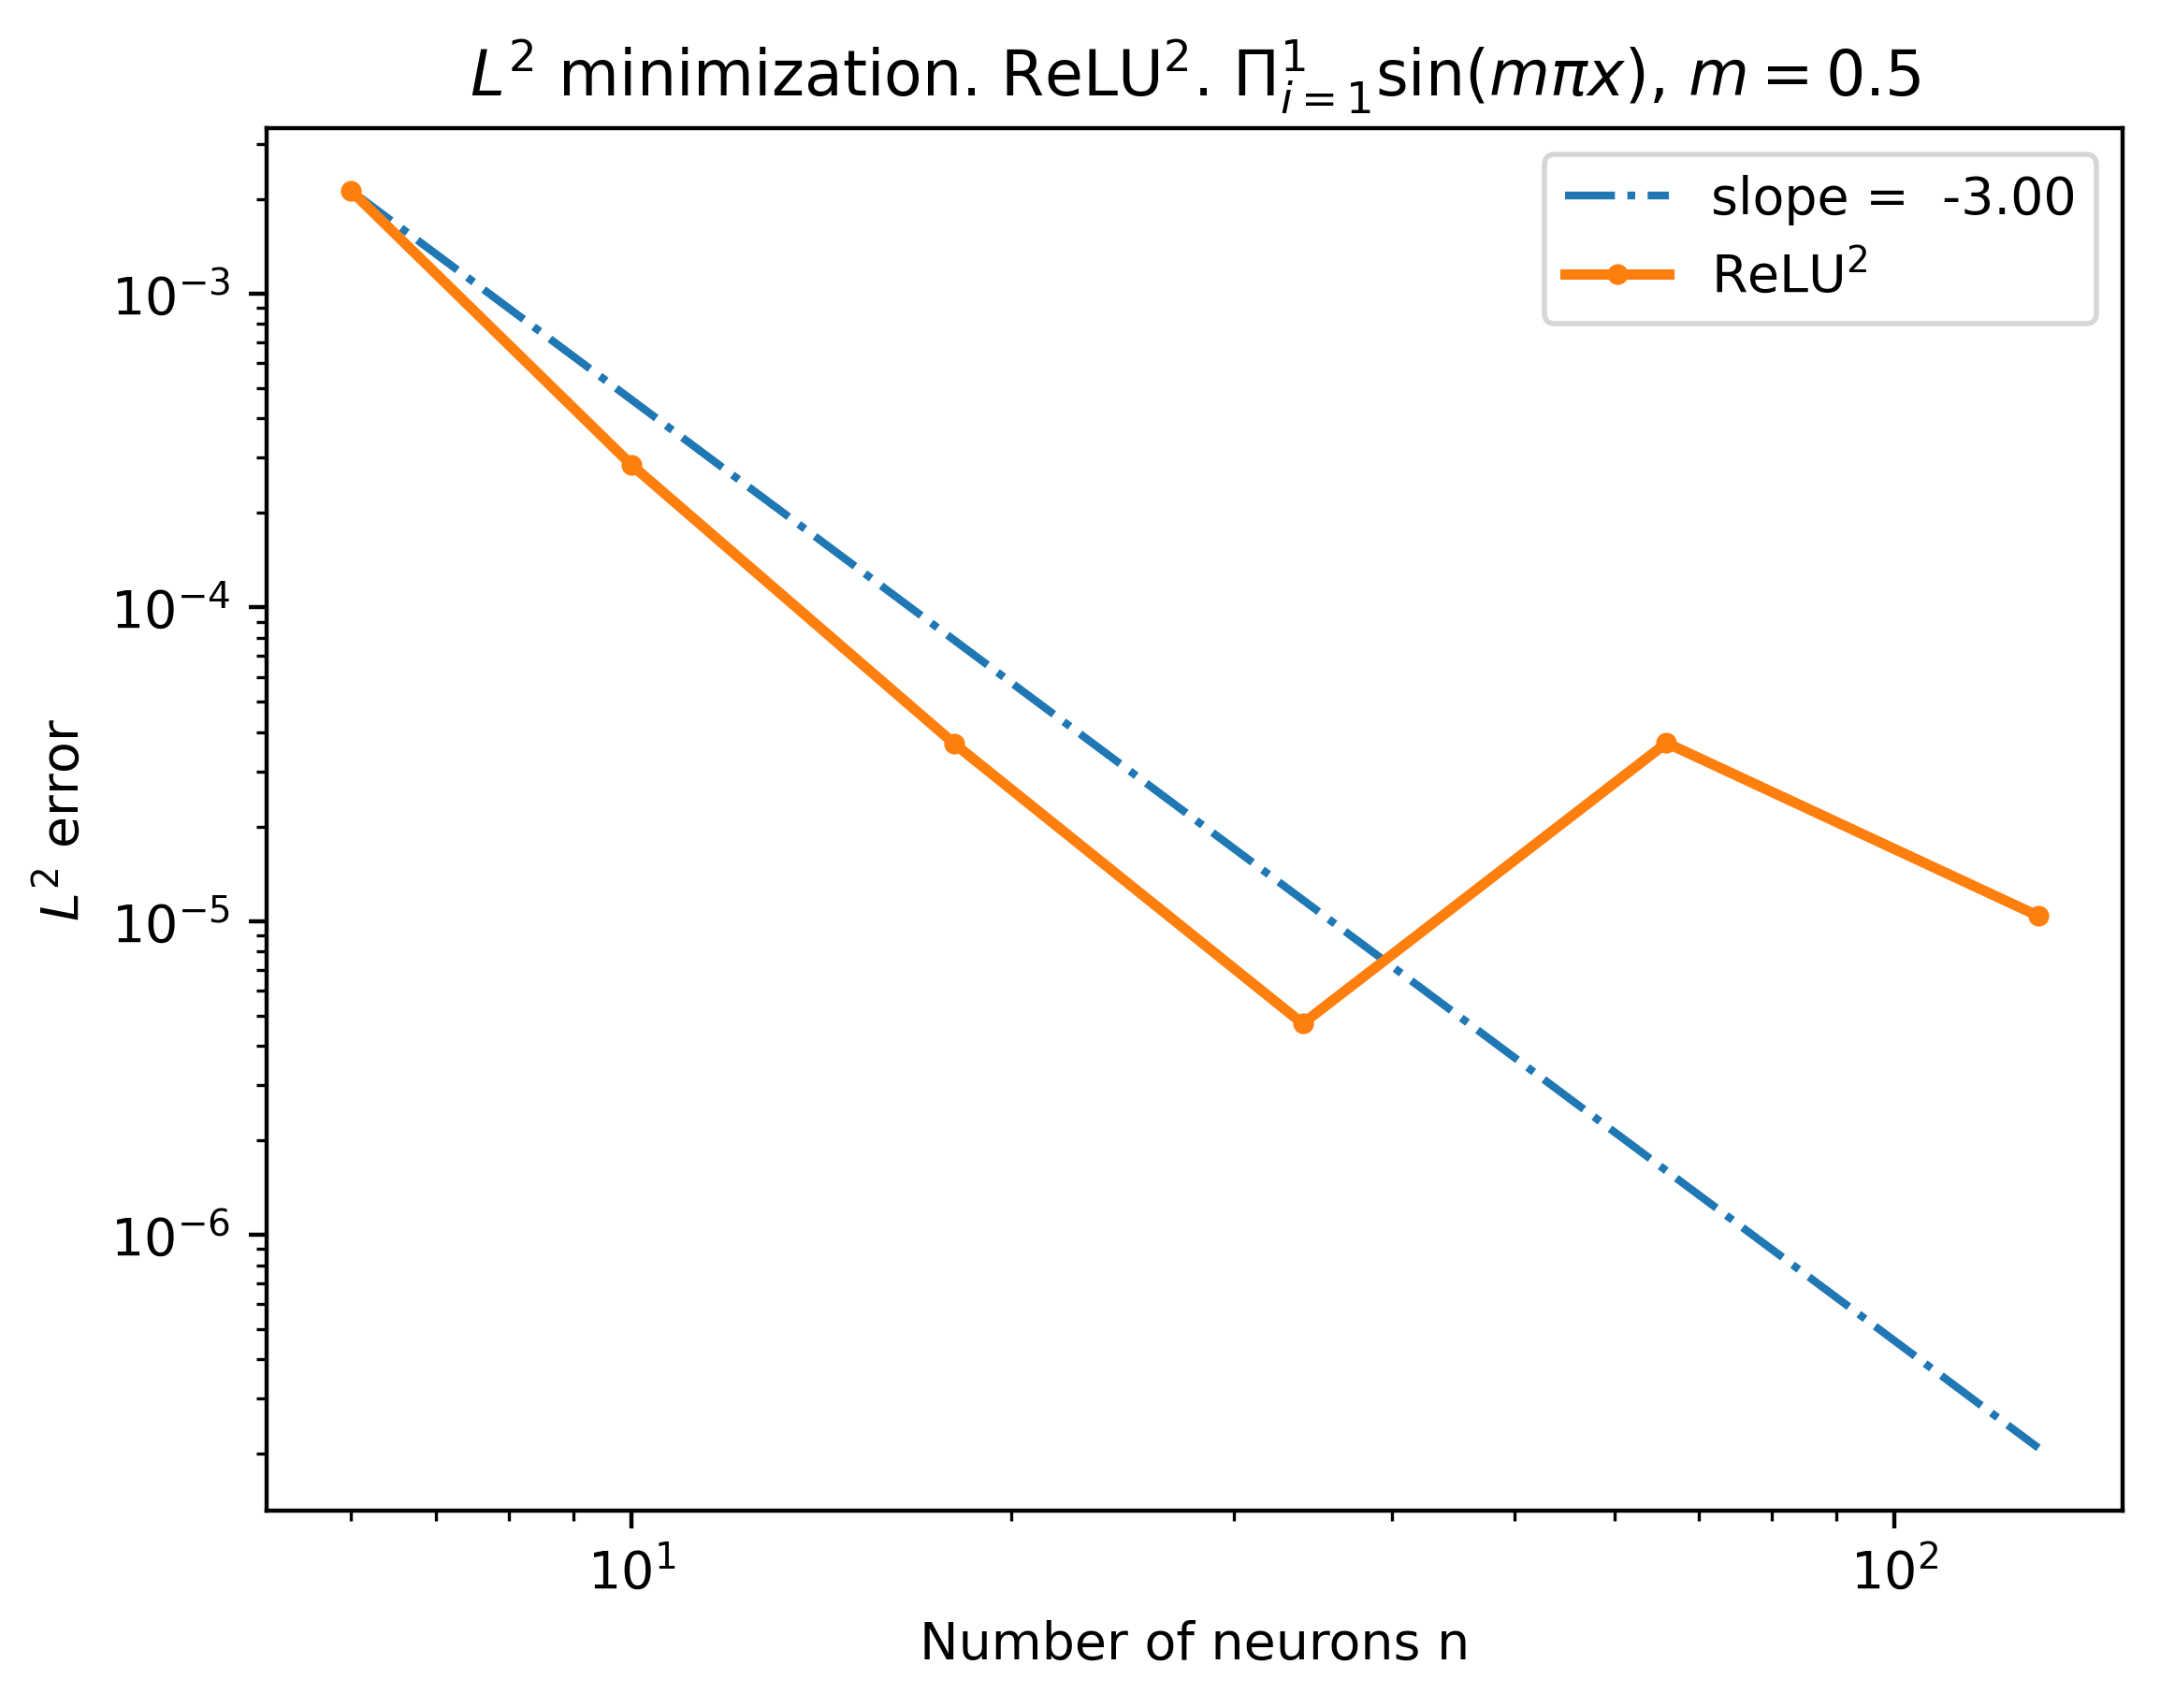

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
6 		 & 2.127e-03 &		 *  \\ \hline  

10 		 &  2.847e-04 &  		 3.94  \\ \hline  

18 		 &  3.686e-05 &  		 3.48  \\ \hline  

34 		 &  4.709e-06 &  		 3.24  \\ \hline  

66 		 &  3.696e-05 &  		 -3.11  \\ \hline  

130 		 &  1.037e-05 &  		 1.87  \\ \hline  



In [55]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
m = 1/2 
def u_exact(x): 
    z = torch.sin(m * pi*x[:,0:1])
    return z 


d = 1 
relu_k = 2  

Nx = 512   
order = 10   
x_l, x_r = -1, 1
integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order)
M = integration_points.size(0)
# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(3,9)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    # my_model = initialize_model_3(my_model).to(device)
    my_model = initialize_model_1d(my_model.cpu()).to(device)
    
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())
actual_neuron_arr = np.array(actual_neuron_list)
mean_err_l2_arr_2 = np.array(err_list_l2)
if relu_k == 1:
    title =f"$L^2$ minimization. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
else:
    title = f"$L^2$ minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)



## 2D example  

Number of neurons removed:  1
Number of neurons left:  7
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005376338958740234
solving Ax = b time taken:  0.014946460723876953
L2 error:  tensor(0.3801, device='cuda:0')
Number of neurons removed:  2
Number of neurons left:  14
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005173683166503906
solving Ax = b time taken:  0.018084049224853516
L2 error:  tensor(0.0840, device='cuda:0')
Number of neurons removed:  4
Number of neurons left:  28
num batch:  2
jac:  cuda:0
assembling the matrix time taken:  0.0007364749908447266
solving Ax = b time taken:  0.030345439910888672
L2 error:  tensor(0.0212, device='cuda:0')
Number of neurons removed:  9
Number of neurons left:  55
num batch:  4
jac:  cuda:0
assembling the matrix time taken:  0.0010876655578613281
solving Ax = b time taken:  0.053019046783447266
L2 error:  tensor(0.0044, device='cuda:0')
Number of neurons removed:  22
Number of neurons left:  106
num b

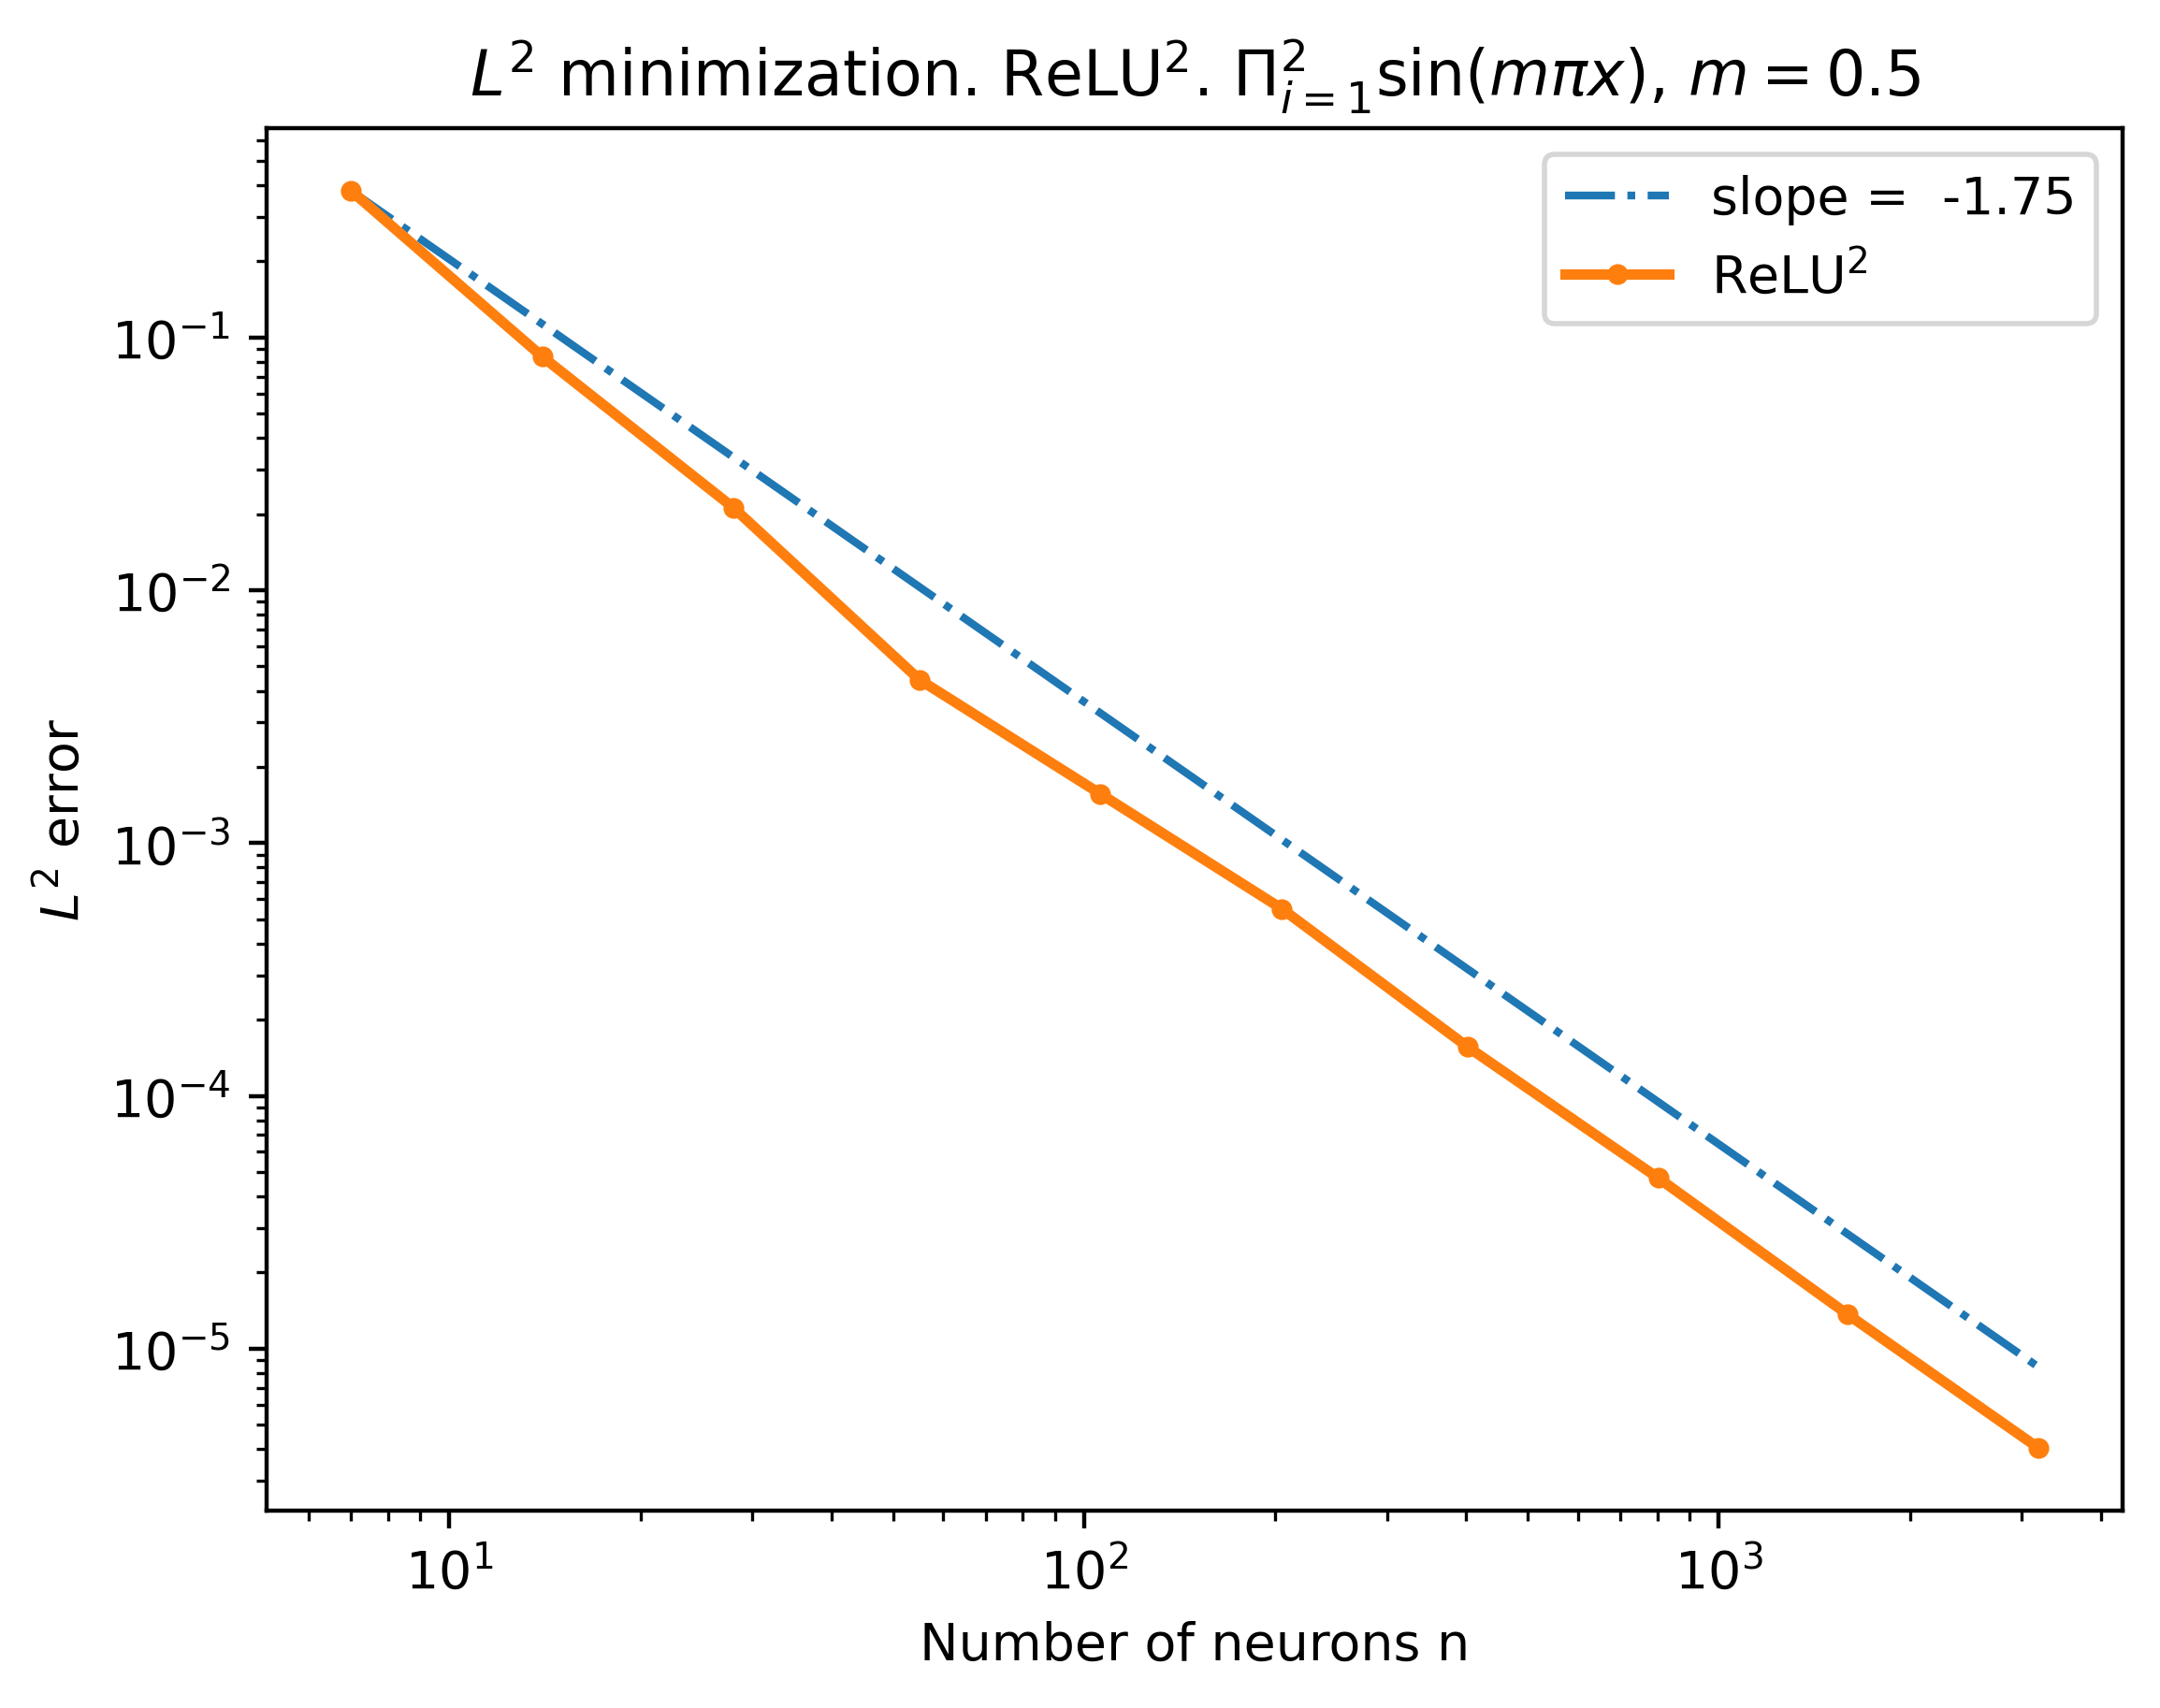

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
7 		 & 3.801e-01 &		 *  \\ \hline  

14 		 &  8.400e-02 &  		 2.18  \\ \hline  

28 		 &  2.123e-02 &  		 1.98  \\ \hline  

55 		 &  4.431e-03 &  		 2.32  \\ \hline  

106 		 &  1.567e-03 &  		 1.58  \\ \hline  

205 		 &  5.490e-04 &  		 1.59  \\ \hline  

402 		 &  1.563e-04 &  		 1.87  \\ \hline  

803 		 &  4.730e-05 &  		 1.73  \\ \hline  

1595 		 &  1.367e-05 &  		 1.81  \\ \hline  

3189 		 &  4.048e-06 &  		 1.76  \\ \hline  



In [17]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
m = 1/2 
def u_exact(x): 
    z = torch.sin(m * pi*x[:,0:1])*torch.sin(m * pi*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
    return z 


d = 2 
relu_k = 2  

Nx = 800   
order = 5 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
M = integration_points.size(0)
# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(3,13)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_3(my_model).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = 2, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())
actual_neuron_arr = np.array(actual_neuron_list)
mean_err_l2_arr_2 = np.array(err_list_l2)
if relu_k == 1:
    title =f"$L^2$ minimization. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
else:
    title = f"$L^2$ minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)



In [82]:
d = 2  
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)
Nx = 400   
order = 5 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
M = integration_points.size(0)
neuron_num_list = [25,50,100,200,400,800,1600]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 2  
for neuron_num in neuron_num_list: 
    my_model = model(2,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_3(my_model).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = 2, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())

    # plot_2D(my_model.cpu()) 
    
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
# print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)


Number of neurons removed:  2
Number of neurons left:  23
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005207061767578125
solving Ax = b time taken:  0.006665229797363281
L2 error:  tensor(0.0020, device='cuda:0')
Number of neurons removed:  6
Number of neurons left:  44
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.00045561790466308594
solving Ax = b time taken:  0.011438846588134766
L2 error:  tensor(0.0004, device='cuda:0')
Number of neurons removed:  16
Number of neurons left:  84
num batch:  2
jac:  cuda:0
assembling the matrix time taken:  0.0006628036499023438
solving Ax = b time taken:  0.026720046997070312
L2 error:  tensor(0.0001, device='cuda:0')
Number of neurons removed:  39
Number of neurons left:  161
num batch:  3
jac:  cuda:0
assembling the matrix time taken:  0.0011174678802490234
solving Ax = b time taken:  0.051653385162353516
L2 error:  tensor(3.9051e-05, device='cuda:0')
Number of neurons removed:  86
Number of neurons left:  

In [7]:
k1 = 1
k2 = 2 
d = 2  
def u_exact(x):
    z = torch.sin(k1 * pi*x[:,0:1])*torch.sin(k2 * pi*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
    return z 

Nx = 400   
order = 5 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
M = integration_points.size(0)
neuron_num_list = [25,50,100,200,400,800,1600]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 2  
for neuron_num in neuron_num_list: 
    my_model = model(2,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_3(my_model).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = 2, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())

    # plot_2D(my_model.cpu()) 
    
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
# print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)


Number of neurons removed:  2
Number of neurons left:  23
num batch:  1
jac:  cpu
assembling the matrix time taken:  3.253553867340088
solving Ax = b time taken:  0.007555723190307617
L2 error:  tensor(0.7539)
Number of neurons removed:  6
Number of neurons left:  44
num batch:  1
jac:  cpu
assembling the matrix time taken:  4.7354700565338135
solving Ax = b time taken:  0.00512385368347168
L2 error:  tensor(0.2949)
Number of neurons removed:  16
Number of neurons left:  84
num batch:  2
jac:  cpu
assembling the matrix time taken:  4.808560132980347
solving Ax = b time taken:  0.007291078567504883
L2 error:  tensor(0.1157)
Number of neurons removed:  39
Number of neurons left:  161
num batch:  3
jac:  cpu
assembling the matrix time taken:  22.268097162246704
solving Ax = b time taken:  0.0019309520721435547
L2 error:  tensor(0.0318)
Number of neurons removed:  86
Number of neurons left:  314
num batch:  5
jac:  cpu
assembling the matrix time taken:  38.81845712661743
solving Ax = b tim

In [105]:
def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 2 * dim **0.5 - dim **0.5   
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 


d = 2  
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)
Nx = 1600   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
M = integration_points.size(0)
neuron_num_list = [6,12,25,50,100,200]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 1
for neuron_num in neuron_num_list: 
    my_model = model(2,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_4(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = 2, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())

    # plot_2D(my_model.cpu()) 
    
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
# print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)


Number of neurons removed:  1
Number of neurons left:  5
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0006761550903320312
solving Ax = b time taken:  0.01916050910949707
L2 error:  tensor(0.0236, device='cuda:0')
Number of neurons removed:  2
Number of neurons left:  10
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005276203155517578
solving Ax = b time taken:  0.021273136138916016
L2 error:  tensor(0.0019, device='cuda:0')
Number of neurons removed:  5
Number of neurons left:  20
num batch:  2
jac:  cuda:0
assembling the matrix time taken:  0.0007510185241699219
solving Ax = b time taken:  0.0317685604095459
L2 error:  tensor(0.0004, device='cuda:0')
Number of neurons removed:  13
Number of neurons left:  37
num batch:  4
jac:  cuda:0
assembling the matrix time taken:  0.0011334419250488281
solving Ax = b time taken:  0.05469059944152832
L2 error:  tensor(9.4862e-05, device='cuda:0')
Number of neurons removed:  29
Number of neurons left:  71
num b

In [88]:
neuron_num = 10 
my_model = model(2,neuron_num,1,relu_k).to(device)
my_model = initialize_model_4(my_model,dim=d).to(device)
print(my_model.fc1.weight)
print(my_model.fc1.bias)


Parameter containing:
tensor([[0.7071, 0.7071],
        [0.7071, 0.7071],
        [0.7071, 0.7071],
        [0.7071, 0.7071],
        [0.7071, 0.7071],
        [0.7071, 0.7071],
        [0.7071, 0.7071],
        [0.7071, 0.7071],
        [0.7071, 0.7071],
        [0.7071, 0.7071]], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([-2.5571,  2.3983, -1.8836,  0.9860,  0.1289, -0.1978,  1.6715,  1.8415,
         1.8636,  0.8607], device='cuda:0', requires_grad=True)


##### special structure 

## 3D  example 

Number of neurons removed:  1
Number of neurons left:  7
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0006511211395263672
solving Ax = b time taken:  0.0027189254760742188
L2 error:  tensor(0.8985, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  16
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.00048732757568359375
solving Ax = b time taken:  0.004426717758178711
L2 error:  tensor(0.5400, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  32
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0004792213439941406
solving Ax = b time taken:  0.0070950984954833984
L2 error:  tensor(0.2337, device='cuda:0')
Number of neurons removed:  3
Number of neurons left:  61
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.00045680999755859375
solving Ax = b time taken:  0.012695550918579102
L2 error:  tensor(0.0720, device='cuda:0')
Number of neurons removed:  9
Number of neurons left:  119
nu

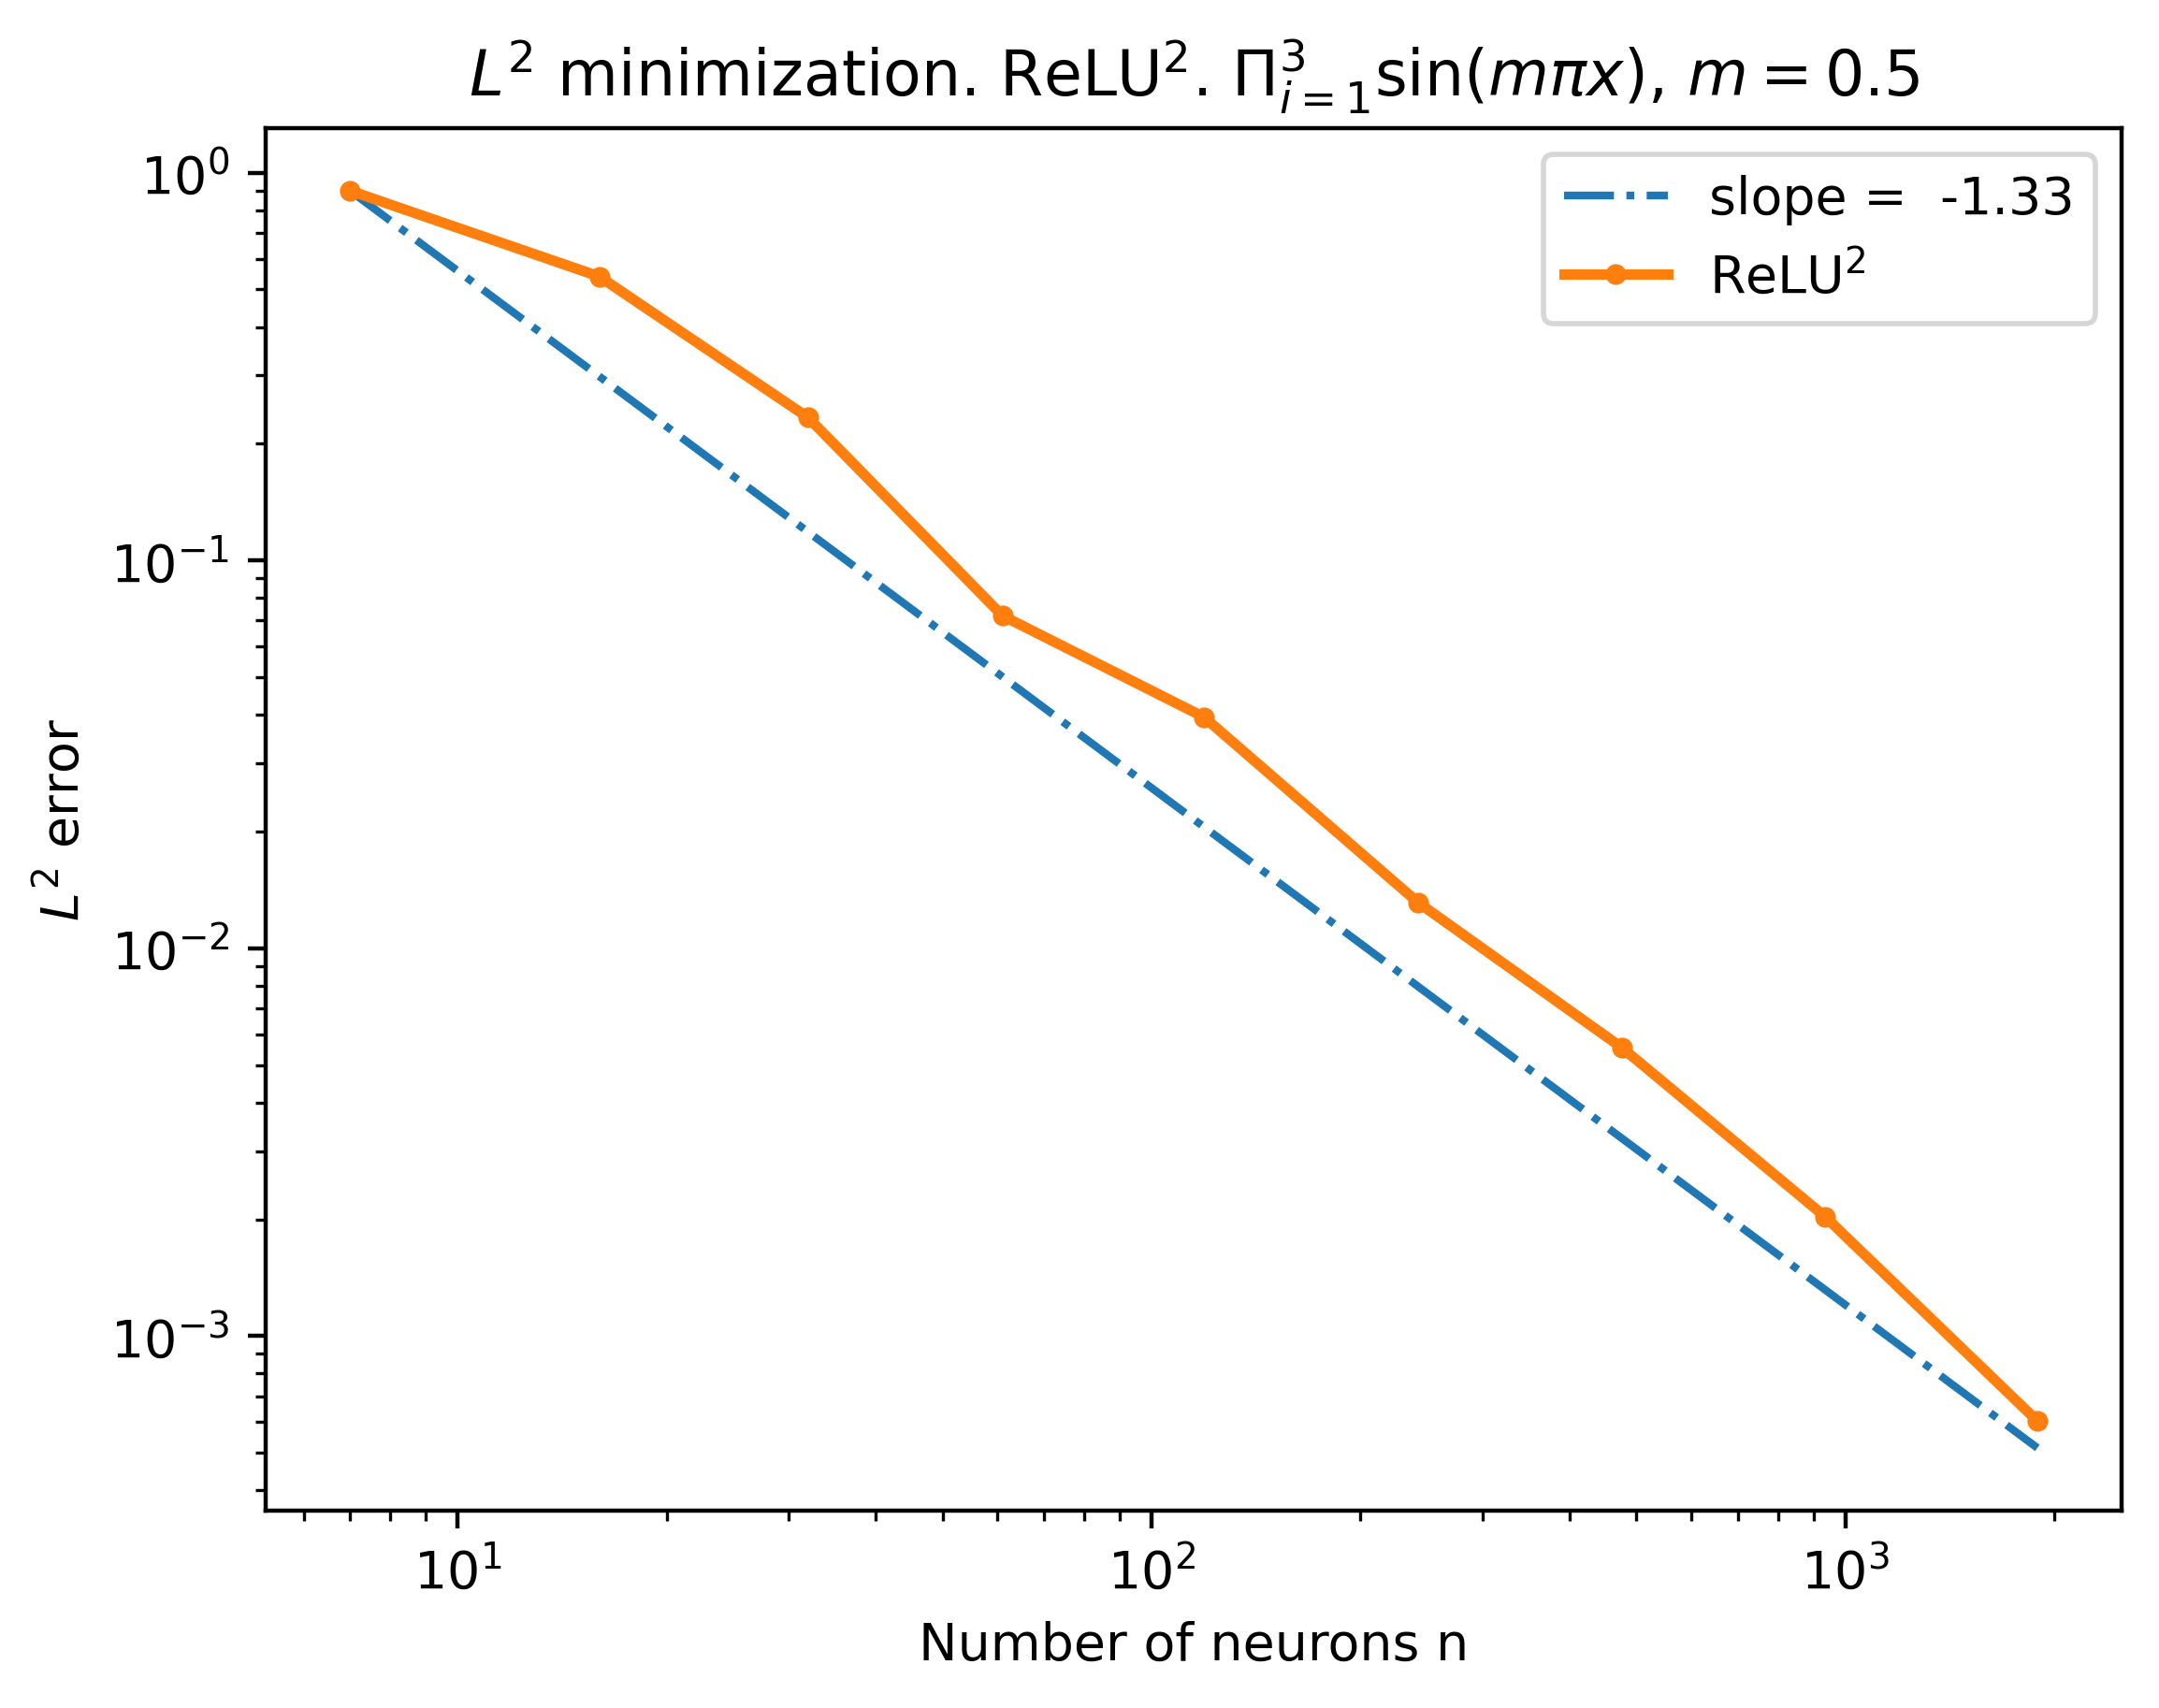

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
7 		 & 8.985e-01 &		 *  \\ \hline  

16 		 &  5.400e-01 &  		 0.62  \\ \hline  

32 		 &  2.337e-01 &  		 1.21  \\ \hline  

61 		 &  7.202e-02 &  		 1.82  \\ \hline  

119 		 &  3.946e-02 &  		 0.90  \\ \hline  

242 		 &  1.314e-02 &  		 1.55  \\ \hline  

476 		 &  5.547e-03 &  		 1.27  \\ \hline  

935 		 &  2.031e-03 &  		 1.49  \\ \hline  

1891 		 &  6.039e-04 &  		 1.72  \\ \hline  



In [ ]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
m = 1/2 
def u_exact(x): 
    z = torch.sin(m * pi*x[:,0:1])*torch.sin(m * pi*x[:,1:2] ) * torch.sin(m * pi*x[:,2:3])  
    return z 

d = 3 
relu_k = 2  

Nx = 50   
order = 3 
integration_weights, integration_points = PiecewiseGQ3D_weights_points(Nx, order,[-1,-1,-1],[1,1,1])
M = integration_points.size(0)
# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(3,12)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())
actual_neuron_arr = np.array(actual_neuron_list)
mean_err_l2_arr_2 = np.array(err_list_l2)
if relu_k == 1:
    title =f"$L^2$ minimization. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
else:
    title = f"$L^2$ minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)



#### Another example 
$$u(x) = \sin(\frac{1}{d} \sum_{i=1 }^d x_i)$$

In [66]:
d = 3  
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)

Nx = 200    
order = 3 
integration_weights, integration_points = PiecewiseGQ3D_weights_points(Nx, order,[-1,-1,-1],[1,1,1])
M = integration_points.size(0)
neuron_num_list = [25,50,100,200,400,800,1600]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 2
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim = d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())


Number of neurons removed:  2
Number of neurons left:  23
num batch:  19
jac:  cuda:0
assembling the matrix time taken:  0.006056547164916992
solving Ax = b time taken:  0.3333878517150879
L2 error:  tensor(0.0434, device='cuda:0')
Number of neurons removed:  1
Number of neurons left:  49
num batch:  40
jac:  cuda:0
assembling the matrix time taken:  0.008247613906860352
solving Ax = b time taken:  0.633479118347168
L2 error:  tensor(0.0053, device='cuda:0')
Number of neurons removed:  6
Number of neurons left:  94
num batch:  76
jac:  cuda:0
assembling the matrix time taken:  0.2532460689544678
solving Ax = b time taken:  1.2287461757659912
L2 error:  tensor(0.0012, device='cuda:0')
Number of neurons removed:  12
Number of neurons left:  188
num batch:  152
jac:  cuda:0
assembling the matrix time taken:  1.561225414276123
solving Ax = b time taken:  1.2335083484649658
L2 error:  tensor(0.0003, device='cuda:0')
Number of neurons removed:  28
Number of neurons left:  372
num batch:  300

In [67]:
d = 3 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)

L2 order: 1.3333333333333335
H1 order: 1.0
$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
23 		 & 4.336e-02 &		 *  \\ \hline  

49 		 &  5.261e-03 &  		 2.79  \\ \hline  

94 		 &  1.166e-03 &  		 2.31  \\ \hline  

188 		 &  2.874e-04 &  		 2.02  \\ \hline  

372 		 &  1.410e-04 &  		 1.04  \\ \hline  

738 		 &  4.750e-05 &  		 1.59  \\ \hline  

1459 		 &  2.304e-05 &  		 1.06  \\ \hline  



##### special initialization 

In [113]:
def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 2 * dim **0.5 - dim **0.5   
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 


d = 3  
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)

Nx = 200    
order = 3 
integration_weights, integration_points = PiecewiseGQ3D_weights_points(Nx, order,[-1,-1,-1],[1,1,1])
M = integration_points.size(0)
neuron_num_list = [6,12,25,50,100,200]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 1
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_4(my_model,dim = d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())


Number of neurons removed:  2
Number of neurons left:  4
num batch:  4
jac:  cuda:0
assembling the matrix time taken:  0.002825498580932617
solving Ax = b time taken:  0.14895915985107422
L2 error:  tensor(0.0091, device='cuda:0')
Number of neurons removed:  3
Number of neurons left:  9
num batch:  8
jac:  cuda:0
assembling the matrix time taken:  0.0034646987915039062
solving Ax = b time taken:  0.20232081413269043
L2 error:  tensor(0.0035, device='cuda:0')
Number of neurons removed:  8
Number of neurons left:  17
num batch:  14
jac:  cuda:0
assembling the matrix time taken:  0.004962444305419922
solving Ax = b time taken:  0.2689828872680664
L2 error:  tensor(0.0007, device='cuda:0')
Number of neurons removed:  18
Number of neurons left:  32
num batch:  26
jac:  cuda:0
assembling the matrix time taken:  0.007333993911743164
solving Ax = b time taken:  0.4213695526123047
L2 error:  tensor(0.0002, device='cuda:0')
Number of neurons removed:  40
Number of neurons left:  60
num batch:  4

In [114]:
d = 3 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)

L2 order: 1.0
H1 order: 0.6666666666666666
$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
4 		 & 9.146e-03 &		 *  \\ \hline  

9 		 &  3.473e-03 &  		 1.19  \\ \hline  

17 		 &  7.043e-04 &  		 2.51  \\ \hline  

32 		 &  1.678e-04 &  		 2.27  \\ \hline  

60 		 &  4.106e-05 &  		 2.24  \\ \hline  

116 		 &  1.019e-05 &  		 2.11  \\ \hline  



## 4D example 

In [27]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
def u_exact(x): 
    z = torch.sin(pi/2*x[:,0:1]) * torch.sin(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3]) * torch.sin(pi/2*x[:,3:4])   
    return z 



Number of neurons removed:  0
Number of neurons left:  64
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005817413330078125
solving Ax = b time taken:  0.0031096935272216797
L2 error:  tensor(0.5583, device='cuda:0')
Number of neurons removed:  3
Number of neurons left:  125
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0004930496215820312
solving Ax = b time taken:  0.006955385208129883
L2 error:  tensor(0.2759, device='cuda:0')
Number of neurons removed:  3
Number of neurons left:  253
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005373954772949219
solving Ax = b time taken:  0.017958879470825195
L2 error:  tensor(0.1035, device='cuda:0')
Number of neurons removed:  9
Number of neurons left:  503
num batch:  2
jac:  cuda:0
assembling the matrix time taken:  0.001008749008178711
solving Ax = b time taken:  0.04761815071105957
L2 error:  tensor(0.0424, device='cuda:0')
Number of neurons removed:  12
Number of neurons left:  1012
n

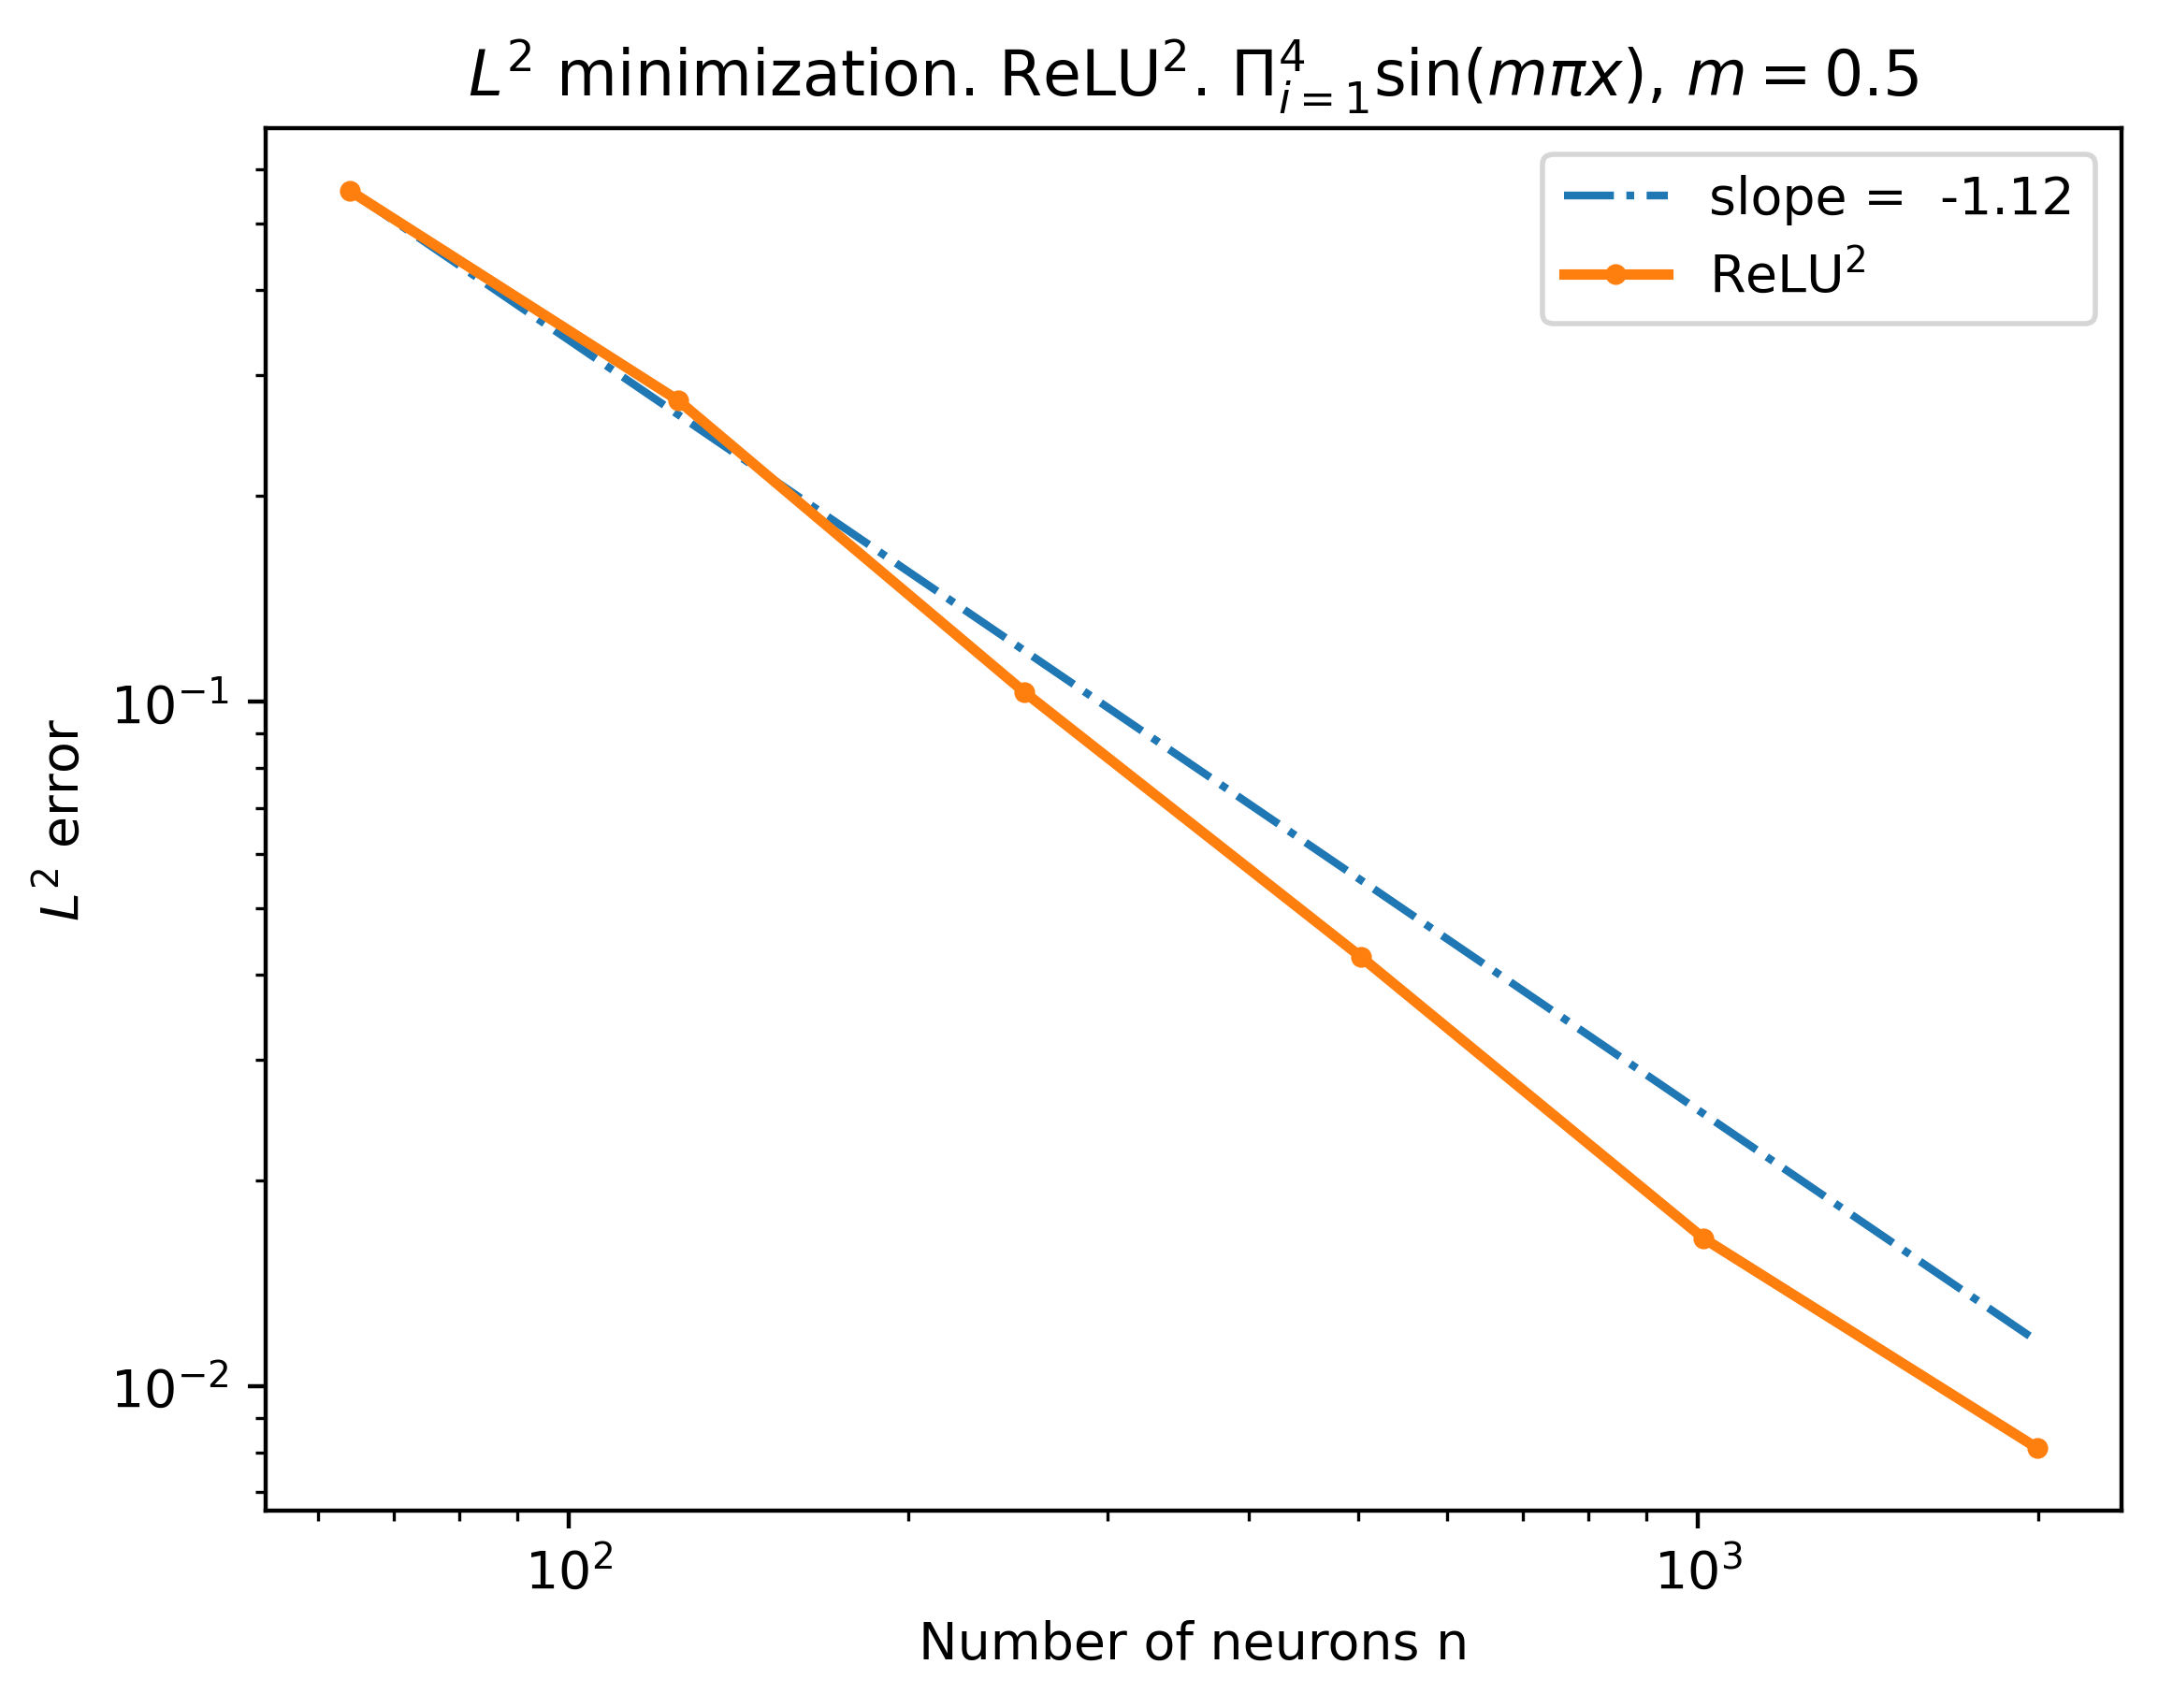

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
64 		 & 5.583e-01 &		 *  \\ \hline  

125 		 &  2.759e-01 &  		 1.05  \\ \hline  

253 		 &  1.035e-01 &  		 1.39  \\ \hline  

503 		 &  4.241e-02 &  		 1.30  \\ \hline  

1012 		 &  1.644e-02 &  		 1.36  \\ \hline  

1996 		 &  8.129e-03 &  		 1.04  \\ \hline  



In [ ]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
m = 1/2 
def u_exact(x): 
    z = torch.sin(m * pi*x[:,0:1])*torch.sin(m * pi*x[:,1:2] ) * torch.sin(m * pi*x[:,2:3]) * torch.sin(m*pi*x[:,3:4])   
    return z 


d = 4 
relu_k = 2  

M = int(8e5)
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M ,d = 4,bl = -1,ur = 1)

# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(6,12)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())
actual_neuron_arr = np.array(actual_neuron_list)
mean_err_l2_arr_2 = np.array(err_list_l2)
if relu_k == 1:
    title =f"$L^2$ minimization. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
else:
    title = f"$L^2$ minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)



In [70]:
d = 4  
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)

M = int(2e6) 
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M, 4, -1, 1) 
neuron_num_list = [25,50,100,200,400,800,1600]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 2 
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 

    # compute the error 
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 #
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)
    
    print("L2 error: ",errl2)
    err_list_l2.append(errl2.item())

Number of neurons removed:  1
Number of neurons left:  24
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0004611015319824219
solving Ax = b time taken:  0.003301858901977539
L2 error:  tensor(0.1260, device='cuda:0')
Number of neurons removed:  1
Number of neurons left:  49
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005469322204589844
solving Ax = b time taken:  0.006239891052246094
L2 error:  tensor(0.0154, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  100
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0006871223449707031
solving Ax = b time taken:  0.014739513397216797
L2 error:  tensor(0.0108, device='cuda:0')
Number of neurons removed:  2
Number of neurons left:  198
num batch:  2
jac:  cuda:0
assembling the matrix time taken:  0.0011851787567138672
solving Ax = b time taken:  0.03847455978393555
L2 error:  tensor(0.0020, device='cuda:0')
Number of neurons removed:  9
Number of neurons left:  391
num 

In [71]:
d = 4 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
# print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)

L2 order: 1.125
$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
24 		 & 1.260e-01 &		 *  \\ \hline  

49 		 &  1.541e-02 &  		 2.94  \\ \hline  

100 		 &  1.079e-02 &  		 0.50  \\ \hline  

198 		 &  1.951e-03 &  		 2.50  \\ \hline  

391 		 &  5.322e-04 &  		 1.91  \\ \hline  

788 		 &  2.218e-04 &  		 1.25  \\ \hline  

1553 		 &  9.834e-05 &  		 1.20  \\ \hline  



In [119]:
def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 2 * dim **0.5 - dim **0.5   
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 

d = 4  
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)


M = int(5e6) 
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M, 4, -1, 1) 
neuron_num_list = [6,12,25,50,100,200,400]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 1
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_4(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 

    # compute the error 
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 #
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)
    
    print("L2 error: ",errl2)
    err_list_l2.append(errl2.item())
d = 4 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
# print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)

Number of neurons removed:  2
Number of neurons left:  4
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0004889965057373047
solving Ax = b time taken:  0.0033698081970214844
L2 error:  tensor(0.0078, device='cuda:0')
Number of neurons removed:  3
Number of neurons left:  9
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005052089691162109
solving Ax = b time taken:  0.004854440689086914
L2 error:  tensor(0.0058, device='cuda:0')
Number of neurons removed:  9
Number of neurons left:  16
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005922317504882812
solving Ax = b time taken:  0.006055593490600586
L2 error:  tensor(0.0012, device='cuda:0')
Number of neurons removed:  21
Number of neurons left:  29
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005257129669189453
solving Ax = b time taken:  0.009753942489624023
L2 error:  tensor(0.0003, device='cuda:0')
Number of neurons removed:  47
Number of neurons left:  53
num b

Number of neurons removed:  0
Number of neurons left:  64
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.007558584213256836
solving Ax = b time taken:  0.00041937828063964844
L2 error:  tensor(0.9811, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  128
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0003955364227294922
solving Ax = b time taken:  0.006894350051879883
L2 error:  tensor(0.7763, device='cuda:0')
Number of neurons removed:  1
Number of neurons left:  255
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0004730224609375
solving Ax = b time taken:  0.018069744110107422
L2 error:  tensor(0.4785, device='cuda:0')
Number of neurons removed:  4
Number of neurons left:  508
num batch:  2
jac:  cuda:0
assembling the matrix time taken:  0.0008535385131835938
solving Ax = b time taken:  0.04880523681640625
L2 error:  tensor(0.2099, device='cuda:0')
Number of neurons removed:  1
Number of neurons left:  1023
num 

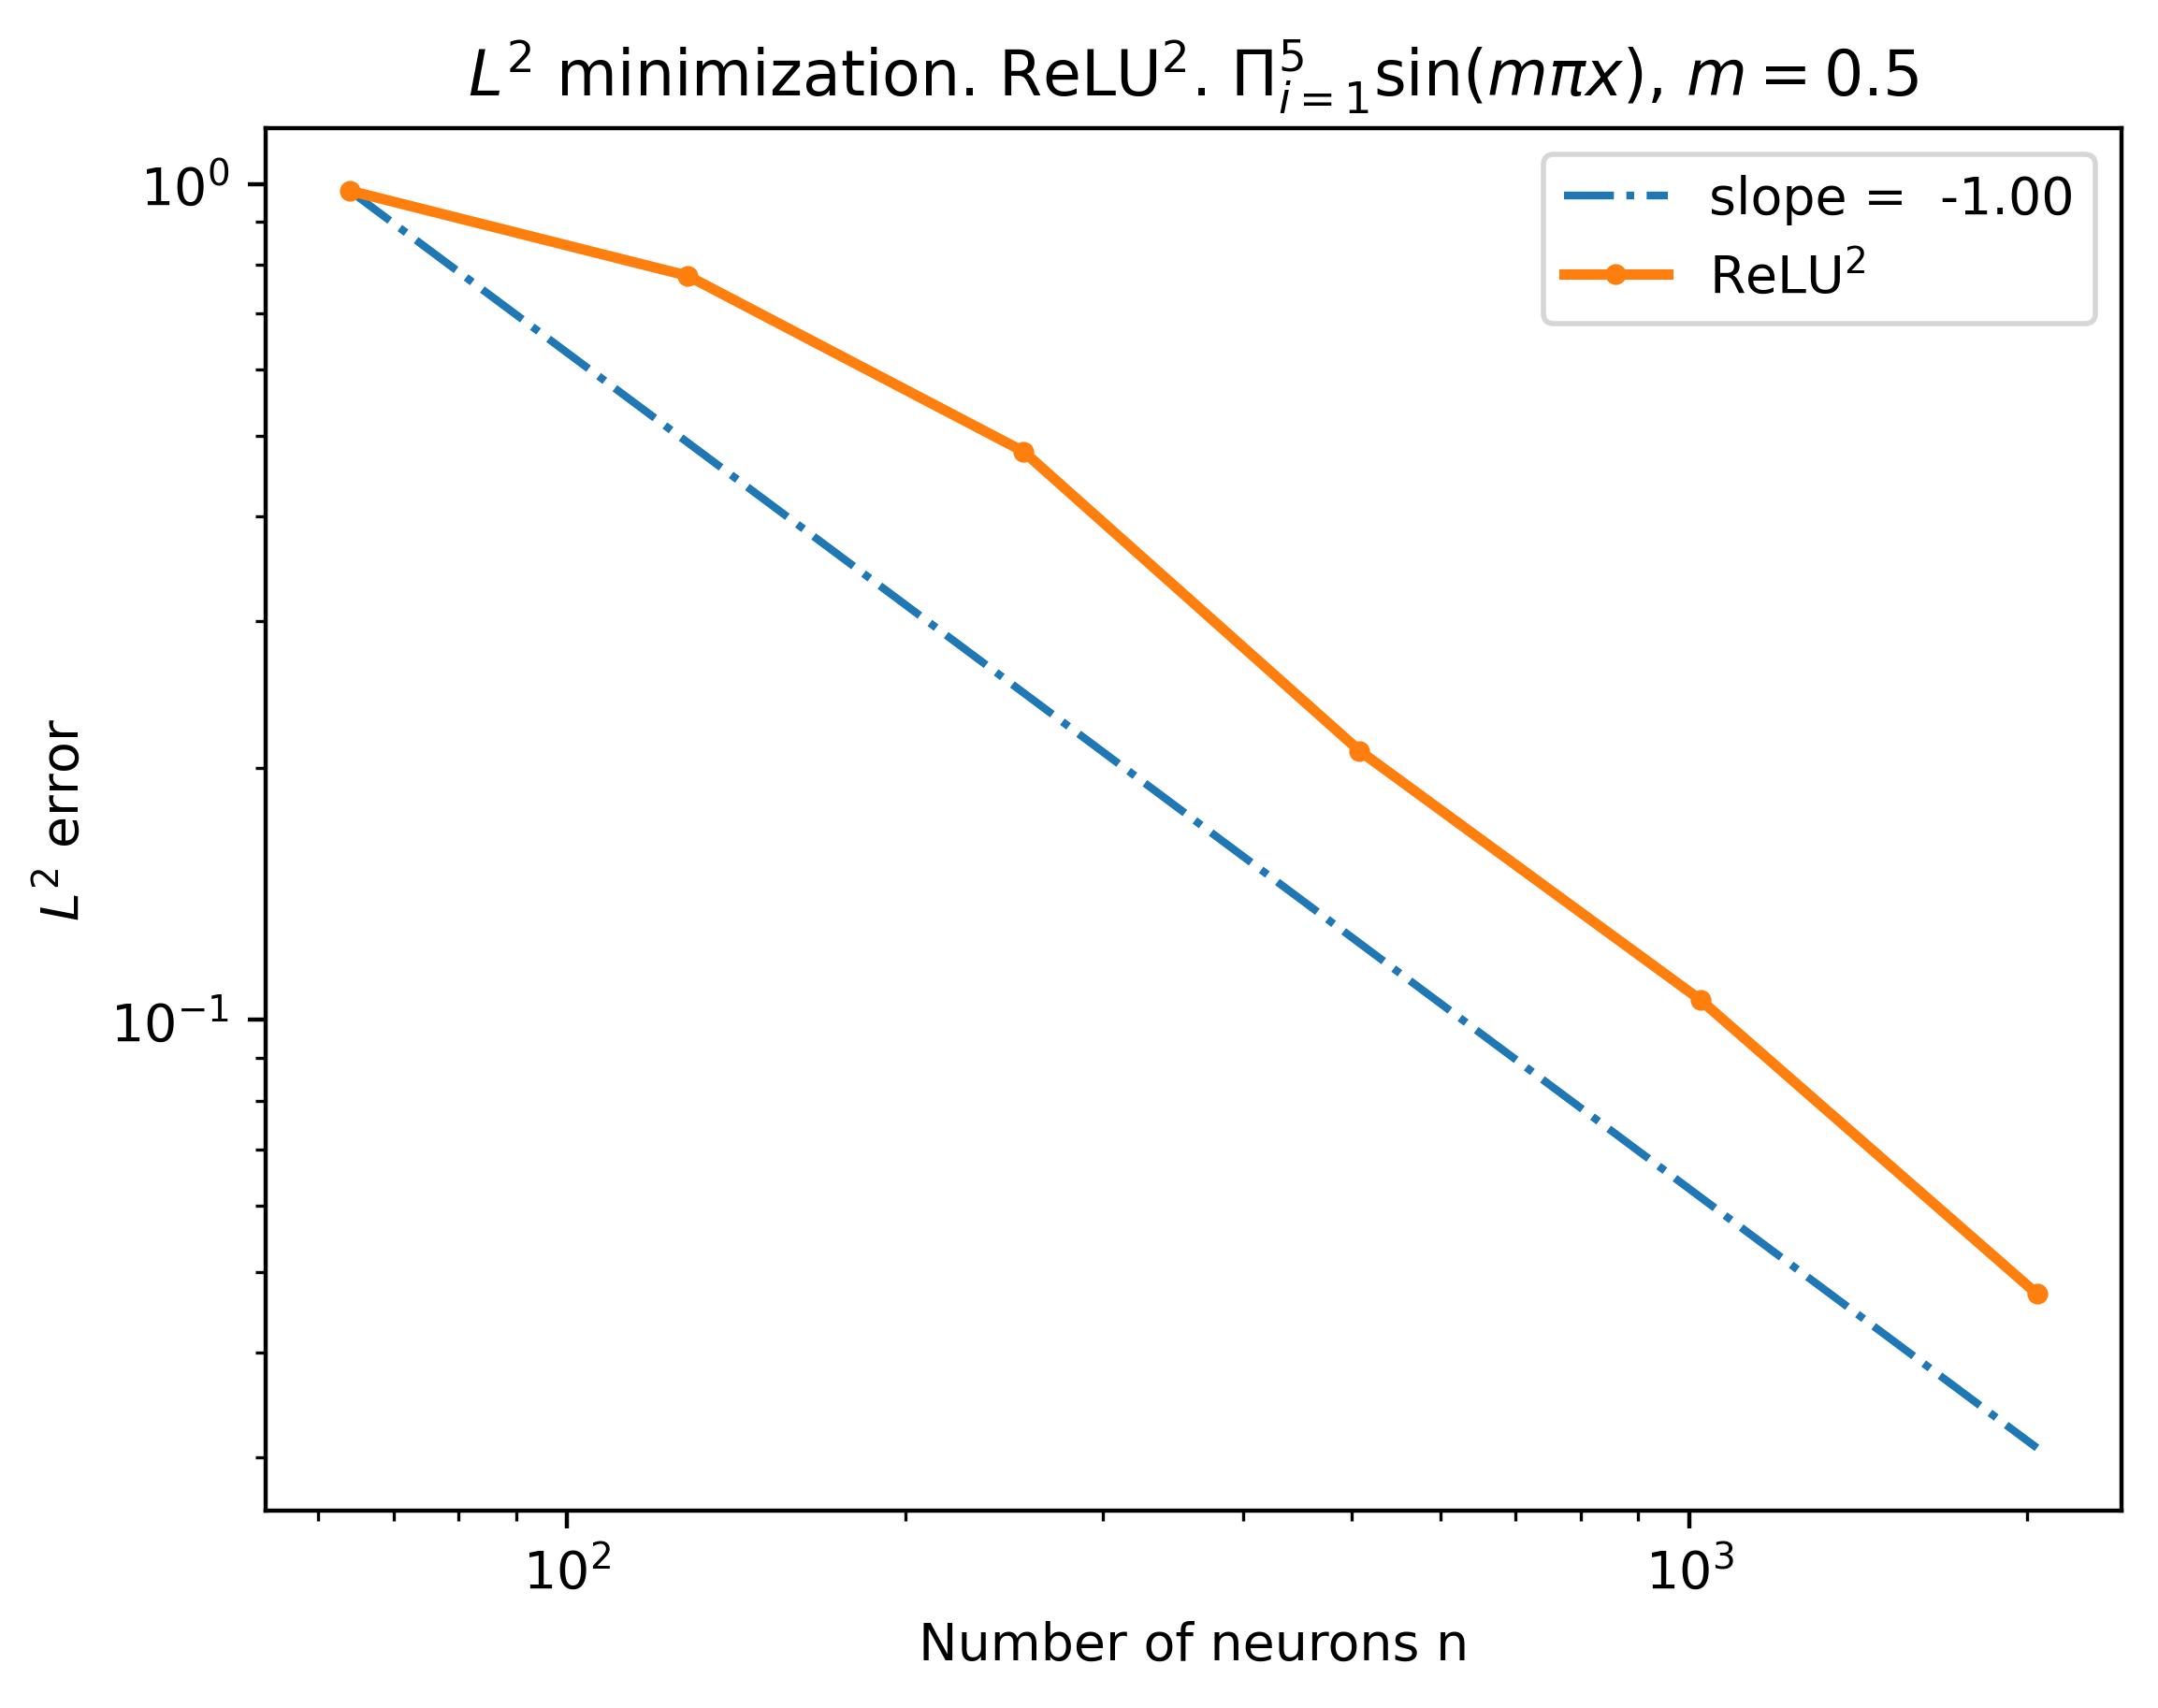

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
64 		 & 9.811e-01 &		 *  \\ \hline  

128 		 &  7.763e-01 &  		 0.34  \\ \hline  

255 		 &  4.785e-01 &  		 0.70  \\ \hline  

508 		 &  2.099e-01 &  		 1.20  \\ \hline  

1023 		 &  1.057e-01 &  		 0.98  \\ \hline  

2040 		 &  4.704e-02 &  		 1.17  \\ \hline  



In [28]:






m = 1/2 
def u_exact(x):
    z = torch.prod(torch.sin(m * pi * x),dim = 1,keepdim = True)
    return z 

d = 5 
relu_k = 2  

M = int(8e5)
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M ,d = d,bl = -1,ur = 1)

# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(6,12)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())
actual_neuron_arr = np.array(actual_neuron_list)
mean_err_l2_arr_2 = np.array(err_list_l2)
if relu_k == 1:
    title =f"$L^2$ minimization. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
else:
    title = f"$L^2$ minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)



In [62]:
d = 5 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
output_convergence_order_l2(actual_neuron_list,err_list_l2)

L2 order: 1.2
$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
25 		 & 9.988e-01 &		 *  \\ \hline  

50 		 &  9.864e-01 &  		 0.02  \\ \hline  

100 		 &  9.265e-01 &  		 0.09  \\ \hline  

199 		 &  5.008e-01 &  		 0.89  \\ \hline  

398 		 &  1.724e-01 &  		 1.54  \\ \hline  

797 		 &  7.768e-02 &  		 1.15  \\ \hline  

1587 		 &  3.366e-02 &  		 1.21  \\ \hline  



In [72]:
d = 5 
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)

M = int(2e7) 
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M, d, -1, 1) 
neuron_num_list = [25,50,100,200,400,800,1600]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 3 
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 

    # compute the error 
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 #
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)
    
    print("L2 error: ",errl2)
    err_list_l2.append(errl2.item())

Number of neurons removed:  1
Number of neurons left:  24
num batch:  2
jac:  cuda:0
assembling the matrix time taken:  0.0009403228759765625
solving Ax = b time taken:  0.033473968505859375
L2 error:  tensor(0.4127, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  50
num batch:  4
jac:  cuda:0
assembling the matrix time taken:  0.0012989044189453125
solving Ax = b time taken:  0.06230354309082031
L2 error:  tensor(0.2475, device='cuda:0')
Number of neurons removed:  2
Number of neurons left:  98
num batch:  8
jac:  cuda:0
assembling the matrix time taken:  0.0019986629486083984
solving Ax = b time taken:  0.13190054893493652
L2 error:  tensor(0.1035, device='cuda:0')
Number of neurons removed:  2
Number of neurons left:  198
num batch:  15
jac:  cuda:0
assembling the matrix time taken:  0.0035855770111083984
solving Ax = b time taken:  0.3136332035064697
L2 error:  tensor(0.0211, device='cuda:0')
Number of neurons removed:  2
Number of neurons left:  398
num bat

In [73]:
d = 5 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
output_convergence_order_l2(actual_neuron_list,err_list_l2)

L2 order: 1.2
$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
24 		 & 4.127e-01 &		 *  \\ \hline  

50 		 &  2.475e-01 &  		 0.70  \\ \hline  

98 		 &  1.035e-01 &  		 1.30  \\ \hline  

198 		 &  2.106e-02 &  		 2.26  \\ \hline  

398 		 &  2.420e-03 &  		 3.10  \\ \hline  

793 		 &  4.079e-04 &  		 2.58  \\ \hline  

1592 		 &  1.026e-04 &  		 1.98  \\ \hline  



In [135]:
def remove_redundant_neuron(my_model, dims = 3, choice = 2): 
    ##  choice 1:  [0,1]^d, choice 2: [-1,1]^d
    def create_mesh_grid(dims, pts):
        mesh = torch.tensor(list(itertools.product(pts,repeat=dims)))
        vertices = mesh.reshape(len(pts) ** dims, -1) 
        return vertices
    counter = 0 
    # positions = torch.tensor([[0.,0.],[0.,1.],[1.,1.],[1.,0.]])
    # pts = torch.tensor([0.,1.]) # for domain [0,1]^d 
    if choice == 1: 
        pts = torch.tensor([0.,1.])
    elif choice == 2:
        pts = torch.tensor([-1.,1.])# for domain [-1,1]^d 
    elif choice == 3:
        pts = torch.tensor([-1./2,1./2])# for domain [-1,1]^d 
    positions = create_mesh_grid(dims,pts) 
    neuron_num = my_model.fc1.bias.size(0)
    relu_k = my_model.k 
    recorded_neurons = []
    poly_dofs = math.comb(relu_k + dims, dims)
    for i in range(neuron_num): 
        w = my_model.fc1.weight.data[i:i+1,:]
        b = my_model.fc1.bias.data[i]
        values = torch.matmul(positions,w.T)
        left_end = - torch.max(values)
        right_end = - torch.min(values)
        offset = (right_end - left_end)/20 #50 
        if b > left_end + offset/2 and b < right_end - offset/2: 
            recorded_neurons.append((w, b))
        elif b >= right_end - offset/2 and counter < poly_dofs:
            recorded_neurons.append((w, b))
            counter += 1

    new_neuron_num = len(recorded_neurons)
    new_model = model(dims, new_neuron_num, 1, k=relu_k).to(device)
    for i, (w, b) in enumerate(recorded_neurons):
        new_model.fc1.weight.data[i:i+1,:] = w
        new_model.fc1.bias.data[i] = b
    print("Number of neurons removed: ", neuron_num - new_neuron_num)
    print("Number of neurons left: ", new_neuron_num)  
    return new_model


def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 2 * dim **0.5 -  1 * dim **0.5
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 

d = 5 
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)


M = int(5e6) 
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M, d, -1, 1) 
neuron_num_list = [6,12,25,50,100,200]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 1
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_4(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 

    # compute the error 
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 #
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)
    
    print("L2 error: ",errl2)
    err_list_l2.append(errl2.item())
d = 5 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
# print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)

Number of neurons removed:  2
Number of neurons left:  4
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.00048160552978515625
solving Ax = b time taken:  0.0039048194885253906
L2 error:  tensor(0.0117, device='cuda:0')
Number of neurons removed:  4
Number of neurons left:  8
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.00035881996154785156
solving Ax = b time taken:  0.00470280647277832
L2 error:  tensor(0.0091, device='cuda:0')
Number of neurons removed:  8
Number of neurons left:  17
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.00036787986755371094
solving Ax = b time taken:  0.006798982620239258
L2 error:  tensor(0.0019, device='cuda:0')
Number of neurons removed:  24
Number of neurons left:  26
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.00035452842712402344
solving Ax = b time taken:  0.009117841720581055
L2 error:  tensor(0.0004, device='cuda:0')
Number of neurons removed:  52
Number of neurons left:  48
nu

Number of neurons removed:  0
Number of neurons left:  64
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0005192756652832031
solving Ax = b time taken:  0.008310317993164062
L2 error:  tensor(0.9981, device='cuda:0')
Number of neurons removed:  1
Number of neurons left:  127
num batch:  1
jac:  cuda:0
assembling the matrix time taken:  0.0004100799560546875
solving Ax = b time taken:  0.018720388412475586
L2 error:  tensor(0.9814, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  256
num batch:  2
jac:  cuda:0
assembling the matrix time taken:  0.0006244182586669922
solving Ax = b time taken:  0.051785945892333984
L2 error:  tensor(0.9029, device='cuda:0')
Number of neurons removed:  1
Number of neurons left:  511
num batch:  4
jac:  cuda:0
assembling the matrix time taken:  0.0012459754943847656
solving Ax = b time taken:  0.13356375694274902
L2 error:  tensor(0.6953, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  1024
nu

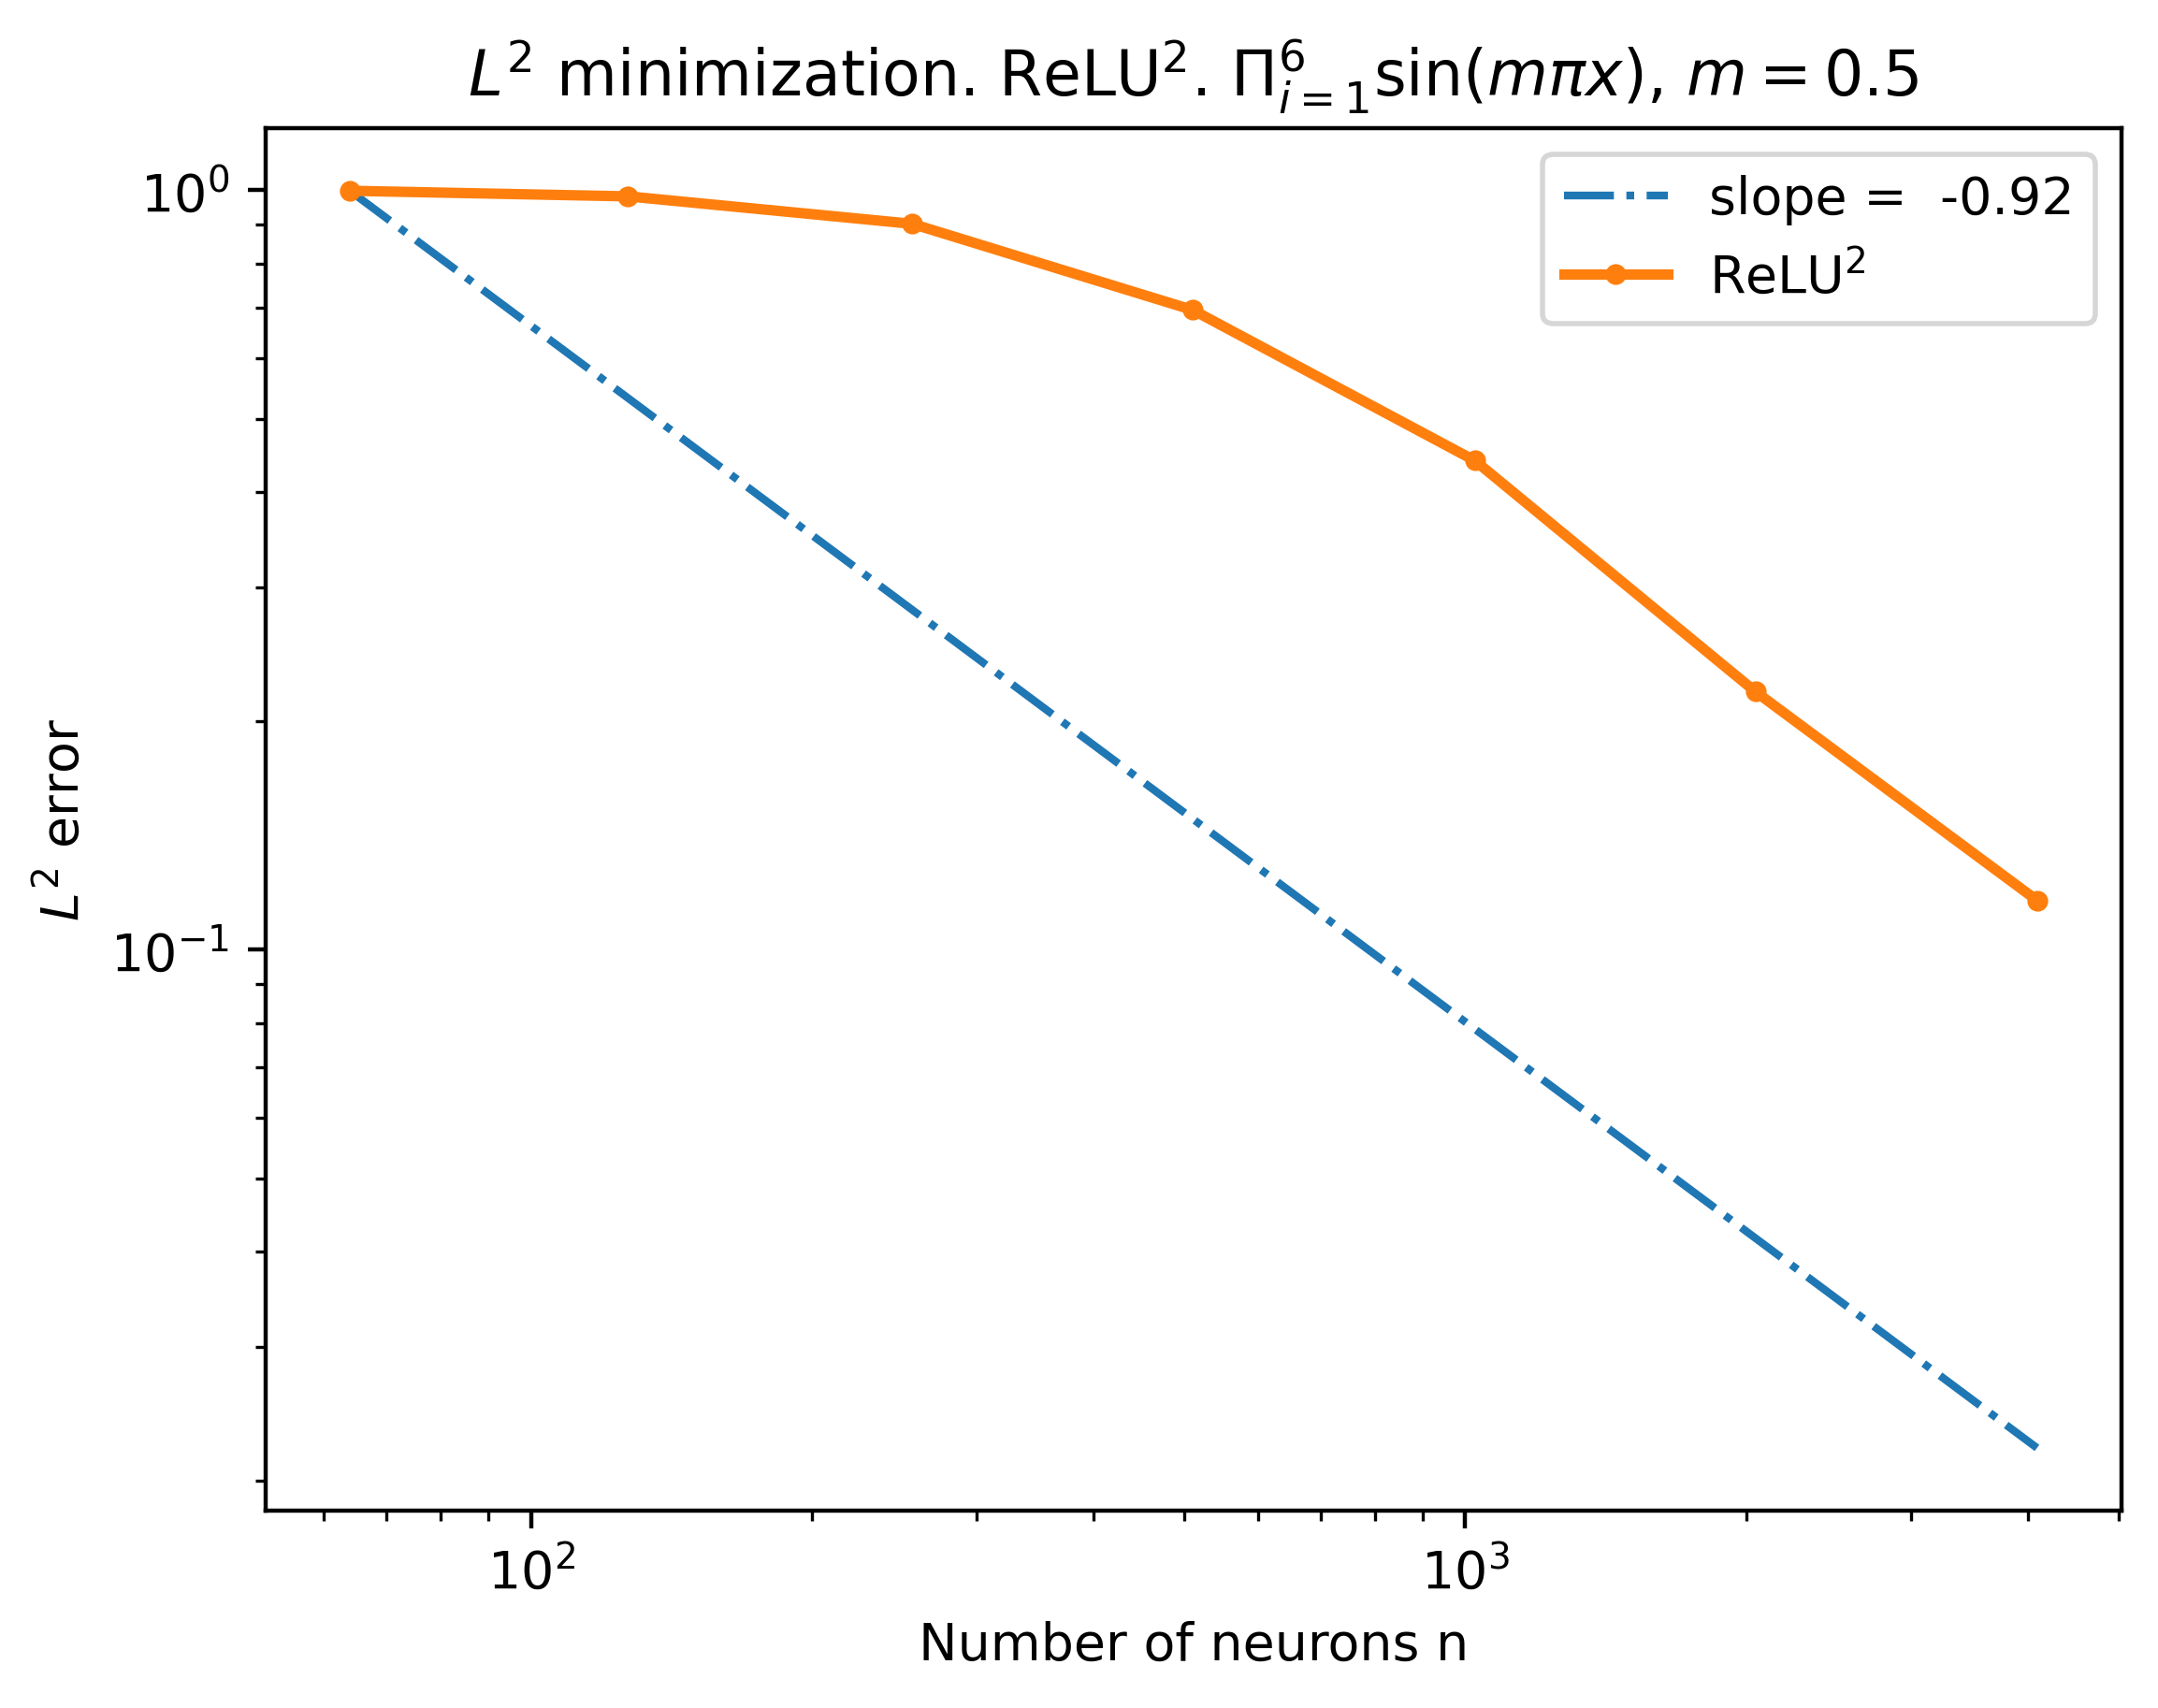

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
64 		 & 9.981e-01 &		 *  \\ \hline  

127 		 &  9.814e-01 &  		 0.02  \\ \hline  

256 		 &  9.029e-01 &  		 0.12  \\ \hline  

511 		 &  6.953e-01 &  		 0.38  \\ \hline  

1024 		 &  4.404e-01 &  		 0.66  \\ \hline  

2044 		 &  2.187e-01 &  		 1.01  \\ \hline  

4092 		 &  1.161e-01 &  		 0.91  \\ \hline  



In [34]:






m = 1/2 
def u_exact(x):
    z = torch.prod(torch.sin(m * pi * x),dim = 1,keepdim = True)
    return z 

d = 6 
relu_k = 2  

M = int(2e6)
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M ,d = d,bl = -1,ur = 1)

# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(6,13)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver='ls',memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())
actual_neuron_arr = np.array(actual_neuron_list)
mean_err_l2_arr_2 = np.array(err_list_l2)
if relu_k == 1:
    title =f"$L^2$ minimization. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
else:
    title = f"$L^2$ minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)



In [64]:
d = 6 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
output_convergence_order_l2(actual_neuron_list,err_list_l2)

L2 order: 1.0833333333333335
$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
25 		 & 9.984e-01 &		 *  \\ \hline  

50 		 &  9.994e-01 &  		 -0.00  \\ \hline  

99 		 &  9.974e-01 &  		 0.00  \\ \hline  

200 		 &  9.695e-01 &  		 0.04  \\ \hline  

400 		 &  7.864e-01 &  		 0.30  \\ \hline  

799 		 &  3.846e-01 &  		 1.03  \\ \hline  

1597 		 &  1.577e-01 &  		 1.29  \\ \hline  

3195 		 &  7.152e-02 &  		 1.14  \\ \hline  



In [75]:
d = 6 
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)

M = int(5e7) 
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M, d, -1, 1) 
neuron_num_list = [25,50,100,200,400,800,1600]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 3 
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 

    # compute the error 
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 #
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)
    
    print("L2 error: ",errl2)
    err_list_l2.append(errl2.item())

Number of neurons removed:  0
Number of neurons left:  25
num batch:  5
jac:  cuda:0
assembling the matrix time taken:  0.001644134521484375
solving Ax = b time taken:  0.09284496307373047
L2 error:  tensor(0.9678, device='cuda:0')
Number of neurons removed:  2
Number of neurons left:  48
num batch:  9
jac:  cuda:0
assembling the matrix time taken:  0.002453327178955078
solving Ax = b time taken:  0.14238691329956055
L2 error:  tensor(0.4142, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  100
num batch:  19
jac:  cuda:0
assembling the matrix time taken:  0.00417637825012207
solving Ax = b time taken:  0.33310437202453613
L2 error:  tensor(0.2105, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  200
num batch:  38
jac:  cuda:0
assembling the matrix time taken:  0.007967948913574219
solving Ax = b time taken:  0.7835638523101807
L2 error:  tensor(0.0728, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  400
num batch: 

In [76]:
d = 6 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
output_convergence_order_l2(actual_neuron_list,err_list_l2)

L2 order: 1.0833333333333335
$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
25 		 & 9.678e-01 &		 *  \\ \hline  

48 		 &  4.142e-01 &  		 1.30  \\ \hline  

100 		 &  2.105e-01 &  		 0.92  \\ \hline  

200 		 &  7.277e-02 &  		 1.53  \\ \hline  

400 		 &  9.118e-03 &  		 3.00  \\ \hline  

800 		 &  2.598e-03 &  		 1.81  \\ \hline  

1597 		 &  6.774e-04 &  		 1.94  \\ \hline  



In [4]:
def remove_redundant_neuron(my_model, dims = 3, choice = 2): 
    ##  choice 1:  [0,1]^d, choice 2: [-1,1]^d
    def create_mesh_grid(dims, pts):
        mesh = torch.tensor(list(itertools.product(pts,repeat=dims)))
        vertices = mesh.reshape(len(pts) ** dims, -1) 
        return vertices
    counter = 0 
    # positions = torch.tensor([[0.,0.],[0.,1.],[1.,1.],[1.,0.]])
    # pts = torch.tensor([0.,1.]) # for domain [0,1]^d 
    if choice == 1: 
        pts = torch.tensor([0.,1.])
    elif choice == 2:
        pts = torch.tensor([-1.,1.])# for domain [-1,1]^d 
    elif choice == 3:
        pts = torch.tensor([-1./2,1./2])# for domain [-1,1]^d 
    positions = create_mesh_grid(dims,pts) 
    neuron_num = my_model.fc1.bias.size(0)
    relu_k = my_model.k 
    recorded_neurons = []
    poly_dofs = math.comb(relu_k + dims, dims)
    for i in range(neuron_num): 
        w = my_model.fc1.weight.data[i:i+1,:]
        b = my_model.fc1.bias.data[i]
        values = torch.matmul(positions,w.T)
        left_end = - torch.max(values)
        right_end = - torch.min(values)
        offset = (right_end - left_end)/20 #50 
        if b > left_end + offset/2 and b < right_end - offset/2: 
            recorded_neurons.append((w, b))
        elif b >= right_end - offset/2 and counter < poly_dofs:
            recorded_neurons.append((w, b))
            counter += 1

    new_neuron_num = len(recorded_neurons)
    new_model = model(dims, new_neuron_num, 1, k=relu_k).to(device)
    for i, (w, b) in enumerate(recorded_neurons):
        new_model.fc1.weight.data[i:i+1,:] = w
        new_model.fc1.bias.data[i] = b
    print("Number of neurons removed: ", neuron_num - new_neuron_num)
    print("Number of neurons left: ", new_neuron_num)  
    return new_model


def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 2 * dim **0.5 -  1 * dim **0.5
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 

d = 6 
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)


M = int(1e8) 
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M, d, -1, 1) 
neuron_num_list = [6,12,25,50,100,200]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 1
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_4(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 

    # compute the error 
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 #
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)
    
    print("L2 error: ",errl2)
    err_list_l2.append(errl2.item())

print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
# print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)

OutOfMemoryError: CUDA out of memory. Tried to allocate 4.47 GiB. GPU 0 has a total capacity of 79.25 GiB of which 283.44 MiB is free. Including non-PyTorch memory, this process has 4.88 GiB memory in use. Process 4022168 has 74.08 GiB memory in use. Of the allocated memory 4.47 GiB is allocated by PyTorch, and 2.00 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)